# AI-Generated vs. Real Image Classification

## Introduction

This task is **binary image classification**: given an RGB image, predict whether it is **AI-generated** or a **real photograph**.

You will first implement a **Vision Transformer (ViT)** **from scratch** in PyTorch (Q1.2): patch embedding, class token, positional embeddings, transformer blocks (self-attention + MLP), and a linear classifier on the **[CLS]** token. **Do not** load pretrained image backbones from `torchvision.models` for that part—build the modules yourself with `torch.nn`.

**In Q1.4**, you will use a **pretrained ViT-B/32** from `torchvision` (ImageNet-1K weights) as a **transfer-learning** baseline: replace the classification head and train (fine-tune) on `AIvsReal`. This contrasts the from-scratch models with a standard large-scale pretrained encoder.

**In Q2**, you will **implement a Swin-style** model with **window attention**, building on your ViT from Q1.2.

Applications include media forensics, dataset auditing, and trust & safety.

### Dataset — `AIvsReal`

Place the dataset folder next to this notebook (or set `DATA_ROOT`). Expected layout:

```
AIvsReal/
  Ai_generated_dataset/   # label 0 — AI-generated images
    animals/
    city/
    food/
    nature/
    people/
  real_dataset/           # label 1 — real photographs
    animals/
    city/
    ...
```

Images may appear in subfolders (collected recursively). Common extensions: `.png`, `.jpg`, `.jpeg`.

**Label convention (fixed for grading):**
- **Class 0 — AI-generated** — all files under `Ai_generated_dataset/`
- **Class 1 — Real** — all files under `real_dataset/`

Default: `DATA_ROOT="./AIvsReal"` (override with environment variable `AI_VS_REAL_ROOT` if needed).


### Evaluation metrics

We report **accuracy** on a held-out validation set. For imbalanced settings, **balanced accuracy**, **F1**, and **AUROC** are also useful; the tutorial implements accuracy and you will extend metrics in the questions.

For binary classification with positive class “Real” (label 1):

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

$$
\text{F1} = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

## Submission

Submitted by **Nguyen Nhat Quang**.

- `Tutorial 05_AI_vs_Real_Classification.ipynb` — this notebook, run top to bottom
- `Nguyen_Nhat_Quang_final_model.pth` — weights of the selected final model (loads on CPU)
- `your_model_weights.pth` — Q1.4 ViT-B/32 fine-tuned state dict, under the name used in the brief
- `Nguyen_Nhat_Quang.xlsx` — test-set results workbook, written by the code in the final section
  (sheets: `Summary`, `Test_Predictions`, `Test_Metrics`, `Model_Comparison`, `Per_Category`,
  `Robustness`, `Q3_2_Bonus`, `Hyperparameters`)



---

## Before starting — runnable tutorial

The cells below form a **complete baseline** (dataset → model → train → validate). Read them before attempting the exam questions.

### Install dependencies

In [1]:
# Dependencies -- install ONLY what is missing.
# (Google Colab already ships torch/torchvision built against its CUDA driver;
#  blindly running `pip install torch` there is slow and can break the GPU build.)
import importlib.util, subprocess, sys

_required = [
    ("torch", "torch"), ("torchvision", "torchvision"), ("matplotlib", "matplotlib"),
    ("tqdm", "tqdm"), ("sklearn", "scikit-learn"), ("PIL", "pillow"),
    ("pandas", "pandas"), ("openpyxl", "openpyxl"),
]
_missing = [pkg for mod, pkg in _required if importlib.util.find_spec(mod) is None]
if _missing:
    print("Installing:", _missing)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_missing], check=True)
else:
    print("All dependencies already present.")

All dependencies already present.


### Environment bootstrap (Colab / local)

This notebook runs unchanged on **Google Colab (GPU)**, on **Apple Silicon (MPS)** and on **CPU**.

**To run on Colab:** upload `AIvsReal_train_test.zip` to your Google Drive (anywhere), then run the
cell below. It mounts Drive, locates the archive, unpacks it to `/content/`, and points
`AI_VS_REAL_ROOT` / `AI_VS_REAL_TEST` at the `train/` and `test/` splits. All deliverables
(`.pth` weights and the results `.xlsx`) are written to `OUT_DIR` and mirrored back to Drive so they
survive the runtime being recycled.

**To run locally:** just keep `AIvsReal_train_test/` next to this notebook — the cell finds it.

In [32]:
import os, sys, glob, zipfile, shutil, datetime

STUDENT_NAME = "Nguyen Nhat Quang"
DATASET_DIRNAME = "AIvsReal_train_test"

IN_COLAB = importlib.util.find_spec("google.colab") is not None


def _is_dataset_dir(p):
    """A valid dataset root holds train/{real_dataset,Ai_generated_dataset}."""
    return (os.path.isdir(os.path.join(p, "train", "real_dataset"))
            and os.path.isdir(os.path.join(p, "train", "Ai_generated_dataset")))


def _bounded_find(base, name, max_depth=3):
    """Depth-limited search (a full recursive glob over Drive is painfully slow)."""
    hits = []
    if not os.path.isdir(base):
        return hits
    base_depth = base.rstrip("/").count("/")
    for dirpath, dirnames, filenames in os.walk(base):
        if dirpath.count("/") - base_depth >= max_depth:
            dirnames[:] = []
        dirnames[:] = [d for d in dirnames if not d.startswith(".")]
        for cand in list(dirnames) + list(filenames):
            if cand == name:
                hits.append(os.path.join(dirpath, cand))
    return sorted(hits)


def locate_dataset():
    for c in (DATASET_DIRNAME,
              os.path.join("AIvsReal", DATASET_DIRNAME),
              os.path.join("..", DATASET_DIRNAME),
              f"/content/{DATASET_DIRNAME}",
              os.path.expanduser(f"~/{DATASET_DIRNAME}")):
        if _is_dataset_dir(c):
            return os.path.abspath(c)
    return None


DATASET_ROOT = locate_dataset()

if DATASET_ROOT is None and IN_COLAB:
    try:
        from google.colab import drive
        if not os.path.isdir("/content/drive/MyDrive"):
            drive.mount("/content/drive")
    except Exception as exc:                                   # pragma: no cover
        print("Drive mount skipped:", exc)

    zips = _bounded_find("/content/drive/MyDrive", f"{DATASET_DIRNAME}.zip", max_depth=3) \
        + sorted(glob.glob("/content/*.zip"))
    if zips:
        print("Unpacking", zips[0], "...")
        with zipfile.ZipFile(zips[0]) as zf:
            zf.extractall("/content")
        DATASET_ROOT = locate_dataset()
    else:
        folders = _bounded_find("/content/drive/MyDrive", DATASET_DIRNAME, max_depth=3)
        folders = [f for f in folders if _is_dataset_dir(f)]
        if folders:
            print("Copying", folders[0], "-> /content (faster than reading over Drive FUSE) ...")
            shutil.copytree(folders[0], f"/content/{DATASET_DIRNAME}")
            DATASET_ROOT = locate_dataset()

assert DATASET_ROOT is not None, (
    f"Could not find '{DATASET_DIRNAME}'.\n"
    f"  Colab : upload {DATASET_DIRNAME}.zip to Google Drive, then re-run this cell.\n"
    f"  Local : put the {DATASET_DIRNAME}/ folder next to this notebook."
)

TRAIN_ROOT = os.path.join(DATASET_ROOT, "train")
TEST_ROOT = os.path.join(DATASET_ROOT, "test")
os.environ["AI_VS_REAL_ROOT"] = TRAIN_ROOT + os.sep          # read by the DATA_ROOT cell below
os.environ["AI_VS_REAL_TEST"] = TEST_ROOT + os.sep

# ---- where the deliverables go --------------------------------------------
OUT_DIR = "/content/outputs" if IN_COLAB else os.path.abspath("./outputs")
os.makedirs(OUT_DIR, exist_ok=True)
DRIVE_OUT = "/content/drive/MyDrive/AIvsReal_outputs" if os.path.isdir("/content/drive/MyDrive") else None
if DRIVE_OUT:
    os.makedirs(DRIVE_OUT, exist_ok=True)


def save_deliverable(src):
    """Mirror a produced file into Google Drive so it outlives the Colab runtime."""
    if DRIVE_OUT and os.path.exists(src):
        shutil.copy2(src, os.path.join(DRIVE_OUT, os.path.basename(src)))
    return src


print(f"Colab            : {IN_COLAB}")
print(f"DATASET_ROOT     : {DATASET_ROOT}")
print(f"  train/         : {sum(len(f) for _, _, f in os.walk(TRAIN_ROOT))} files")
print(f"  test/          : {sum(len(f) for _, _, f in os.walk(TEST_ROOT))} files")
print(f"OUT_DIR          : {OUT_DIR}")
print(f"Drive mirror     : {DRIVE_OUT}")
print(f"Started          : {datetime.datetime.now():%Y-%m-%d %H:%M:%S}")

Colab            : True
DATASET_ROOT     : /content/AIvsReal_train_test
  train/         : 895 files
  test/          : 100 files
OUT_DIR          : /content/outputs
Drive mirror     : /content/drive/MyDrive/AIvsReal_outputs
Started          : 2026-09-16 17:41:47


### Imports

In [3]:
import os
import random
import sys

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.io import read_image
import matplotlib.pyplot as plt
from tqdm import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


def get_loader_kwargs(default_num_workers=2):
    requested = int(os.environ.get("AI_VS_REAL_NUM_WORKERS", default_num_workers))
    safe_num_workers = 0 if sys.platform == "darwin" else requested
    return {
        "num_workers": safe_num_workers,
        "pin_memory": torch.cuda.is_available(),
    }


def train_val_indices_balanced_binary(pairs, val_fraction=0.15, seed=42):
    """Return (train_indices, val_indices); val has equal counts for class 0 and 1."""
    rng = random.Random(seed)
    idx0 = [i for i, (_, y) in enumerate(pairs) if y == 0]
    idx1 = [i for i, (_, y) in enumerate(pairs) if y == 1]
    n_total = len(pairs)
    n_val_target = max(2, int(val_fraction * n_total))
    k = n_val_target // 2
    k = min(k, len(idx0), len(idx1))
    rng.shuffle(idx0)
    rng.shuffle(idx1)
    val_set = set(idx0[:k] + idx1[:k])
    train_idx = [i for i in range(n_total) if i not in val_set]
    val_idx = list(val_set)
    return train_idx, val_idx

In [4]:
# Device: CUDA (Colab) > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("cuda |", torch.cuda.get_device_name(0))
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("mps | Apple Silicon GPU")
else:
    device = torch.device("cpu")
    print("cpu")
print(device)

cuda | Tesla T4
cuda


### Dataset paths

Point `DATA_ROOT` at the directory that **directly contains** `Ai_generated_dataset` and `real_dataset` (default `./AIvsReal`). You can override with the environment variable `AI_VS_REAL_ROOT`.

The next code cell walks all images under `Ai_generated_dataset/**` (label 0) and `real_dataset/**` (label 1).


In [5]:
# --- AIvsReal: DATA_ROOT must contain Ai_generated_dataset/ and real_dataset/ ---
DATA_ROOT = os.environ.get("AI_VS_REAL_ROOT", "./AIvsReal_train_test/train/")

IMG_EXT = (".jpg", ".jpeg", ".png", ".webp", ".bmp")


def collect_labeled_paths(root):
    """
    AIvsReal layout:
      <root>/Ai_generated_dataset/<category>/... -> label 0 (AI)
      <root>/real_dataset/<category>/...        -> label 1 (Real)
    All image files are collected recursively.
    """
    pairs = []
    specs = [
        (os.path.join(root, "Ai_generated_dataset"), 0),
        (os.path.join(root, "real_dataset"), 1),
    ]
    for folder, label in specs:
        if not os.path.isdir(folder):
            continue
        for dirpath, _, filenames in os.walk(folder):
            for fn in filenames:
                low = fn.lower()
                if any(low.endswith(ext) for ext in IMG_EXT):
                    pairs.append((os.path.join(dirpath, fn), label))
    return pairs


all_pairs = collect_labeled_paths(DATA_ROOT)
n_ai = sum(1 for _, y in all_pairs if y == 0)
n_real = sum(1 for _, y in all_pairs if y == 1)
print(f"Found {len(all_pairs)} images (AI={n_ai}, Real={n_real}) under DATA_ROOT={DATA_ROOT!r}")
if len(all_pairs) == 0:
    print("Check DATA_ROOT: expected subfolders Ai_generated_dataset/ and real_dataset/.")

Found 895 images (AI=200, Real=695) under DATA_ROOT='/content/AIvsReal_train_test/train/'


#### Optional — adding your own AI-generated images

The tutorial brief invites you to expand the training set with extra AI images (Nano Banana, social media, …).
`collect_labeled_paths` walks **recursively**, so nothing here needs changing: drop new files into any
subfolder of `AIvsReal_train_test/train/Ai_generated_dataset/` (e.g. a new `train/Ai_generated_dataset/mine/`)
and re-run from this cell. `compute_class_weights` in Q1.3 recomputes the imbalance automatically.

**One thing to get right when you do.** Q3.1 shows the two classes in this dataset are already perfectly
separated by file format — AI is square PNG, Real is ~1080 px JPEG. If you add new AI images as PNGs you will
*strengthen* that shortcut and your accuracy will go up for the wrong reason. Save them the way the real photos
are stored — **JPEG, ~1080 px on the long side, non-square** — so the extra data teaches the model about image
content instead of about codecs:

```python
from PIL import Image
im = Image.open("my_ai_image.png").convert("RGB")
im.thumbnail((1080, 1080))
im.save("train/Ai_generated_dataset/mine/ai_001.jpg", "JPEG", quality=92)
```

In [6]:
class AiVsRealDataset(Dataset):
    """Loads images from (path, label) list; RGB uint8 -> float tensor [0,1]."""

    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path, y = self.pairs[idx]
        img = read_image(path)
        if img.shape[0] == 1:
            img = img.repeat(3, 1, 1)
        elif img.shape[0] > 3:
            img = img[:3]
        img = img.float() / 255.0
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(y, dtype=torch.long)


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = train_transform

full_ds = AiVsRealDataset(all_pairs, transform=train_transform)
n_total = len(full_ds)
train_idx, val_idx = train_val_indices_balanced_binary(all_pairs, val_fraction=0.15, seed=42)
train_ds = Subset(full_ds, train_idx)
val_ds = Subset(full_ds, val_idx)
n_train, n_val = len(train_ds), len(val_ds)

# get_loader_kwargs() is the helper defined in the imports cell: it disables worker
# processes on macOS and only pins memory when CUDA is actually available.
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, **get_loader_kwargs())
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, **get_loader_kwargs())
print(f"train={n_train}, val={n_val} (val is 1:1 AI vs real)")

train=761, val=134 (val is 1:1 AI vs real)


#### Visualize a few samples

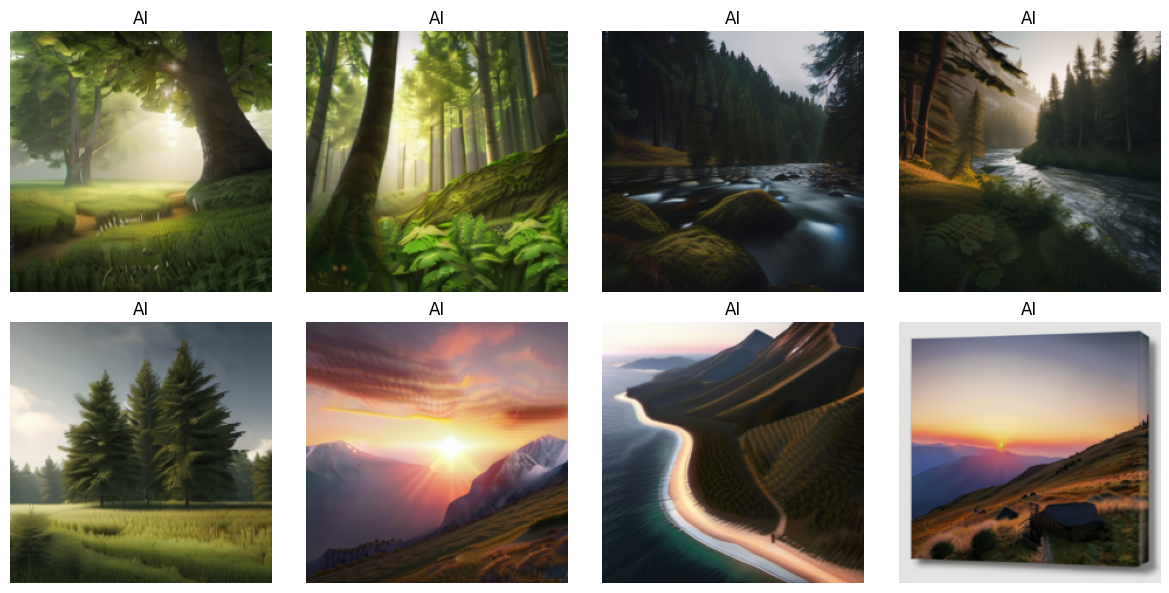

In [7]:
def denormalize(t):
    x = t.clone().cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    x = (x * std + mean).clamp(0, 1)
    return x

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()
for i in range(min(8, len(train_ds))):
    im, lab = train_ds[i]
    axes[i].imshow(denormalize(im).permute(1, 2, 0).numpy())
    axes[i].set_title("AI" if lab.item() == 0 else "Real")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Runnable baseline: ViT from scratch

Below is a **deliberately weak** tutorial ViT (easy for your later models to beat on val): patch size **16**, embedding dim **64**, **2** transformer layers, **2** heads, dropout **0.2**, input **224×224**. All of it is plain `torch.nn` — **no** pretrained weights and **no** importing a ready-made Vision Transformer class from `torchvision`. Read the implementation, then work through Q1.


In [8]:
class PatchEmbedding(nn.Module):
    # Conv patchify: (B,3,H,W) -> (B, N, D)
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=192):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, drop=0.1, attn_drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=attn_drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hid = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hid),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(hid, dim),
            nn.Dropout(drop),
        )

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class VisionTransformerScratch(nn.Module):
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_chans=3,
        num_classes=2,
        embed_dim=192,
        depth=6,
        num_heads=3,
        mlp_ratio=4.0,
        drop_rate=0.1,
        attn_drop=0.0,
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        n_p = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_p + 1, embed_dim))
        self.pos_drop = nn.Dropout(drop_rate)
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(embed_dim, num_heads, mlp_ratio, drop_rate, attn_drop)
                for _ in range(depth)
            ]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        b = x.shape[0]
        x = self.patch_embed(x)
        cls = self.cls_token.expand(b, -1, -1)
        x = torch.cat((cls, x), dim=1)
        x = self.pos_drop(x + self.pos_embed)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return self.head(x[:, 0])


def build_vit_baseline(num_classes=2):
    # Weaker than Q1.2 student target (192/6/3): isolate the tutorial baseline.
    return VisionTransformerScratch(
        num_classes=num_classes,
        embed_dim=64,
        depth=2,
        num_heads=2,
        drop_rate=0.2,
    )


baseline = build_vit_baseline().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(baseline.parameters(), lr=1e-4, weight_decay=0.05)


In [9]:
def accuracy_from_logits(logits, y):
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()


def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss, total_acc, n = 0.0, 0.0, 0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        if train_mode:
            optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        if train_mode:
            loss.backward()
            optimizer.step()
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs
    return total_loss / n, total_acc / n

In [10]:
# Baseline tutorial only (weak on purpose; more epochs on GPU if you want higher acc)
for epoch in range(1):
    tr_loss, tr_acc = run_epoch(baseline, train_loader, criterion, optimizer)
    va_loss, va_acc = run_epoch(baseline, val_loader, criterion, None)
    print(f"epoch {epoch+1}: train loss={tr_loss:.4f} acc={tr_acc:.4f} | val loss={va_loss:.4f} acc={va_acc:.4f}")

torch.save(baseline.state_dict(), "./baseline_vit_scratch.pth")
print("Saved baseline_vit_scratch.pth")


epoch 1: train loss=0.5015 acc=0.7556 | val loss=0.9691 acc=0.5224
Saved baseline_vit_scratch.pth


---

## Q1 — Core implementation (42 pts)

Complete the missing code. Do **not** remove the `###YOUR CODE HERE###` markers.


### Q1.1 Data augmentation for classification (7 pts)

Augment **training** images only (not validation). Use `torchvision.transforms.v2` **or** apply transforms on the **PIL** path if you prefer; here we keep tensor-based pipeline and use `transforms` on float tensors via **RandomApply** / custom — simplest: use **v2** transforms on uint8 before normalize.

**Requirement:** fill **2 lines** using PyTorch APIs:

1. Random horizontal flip with probability **0.5**
2. Random rotation with angle in **[-10, 10]** degrees

Hint: `transforms.RandomHorizontalFlip`, `transforms.RandomRotation` in a `Compose` applied to **PIL** in `__getitem__`, or use `torchvision.transforms.v2`.

In [11]:
from PIL import Image


class AiVsRealDatasetAugmented(Dataset):
    """Same as before but reads PIL for geom augment, then to tensor + normalize."""

    def __init__(self, pairs, train=True):
        self.pairs = pairs
        self.train = train
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        # Built once in __init__ (not per __getitem__) -- the modules are stateless and
        # re-creating them for every sample is pure overhead in the DataLoader workers.
        self.geom_augment = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=(-10, 10)),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path, y = self.pairs[idx]
        pil = Image.open(path).convert("RGB")
        pil = transforms.Resize((224, 224))(pil)
        if self.train:
            ###YOUR CODE HERE###
            # Q1.1 line 1: RandomHorizontalFlip(p=0.5)
            pil = transforms.RandomHorizontalFlip(p=0.5)(pil)
            # Q1.1 line 2: RandomRotation(degrees=(-10, 10))
            pil = transforms.RandomRotation(degrees=(-10, 10))(pil)
            ###END OF YOUR CODE###
        t = transforms.ToTensor()(pil)
        t = self.normalize(t)
        return t, torch.tensor(y, dtype=torch.long)


aug_train_ds = AiVsRealDatasetAugmented(all_pairs, train=True)
aug_val_ds = AiVsRealDatasetAugmented(all_pairs, train=False)
train_idx, val_idx = train_val_indices_balanced_binary(all_pairs, val_fraction=0.15, seed=42)
train_subset = Subset(aug_train_ds, train_idx)
val_subset = Subset(aug_val_ds, val_idx)
train_loader_aug = DataLoader(train_subset, batch_size=32, shuffle=True, **get_loader_kwargs())
val_loader_aug = DataLoader(val_subset, batch_size=32, shuffle=False, **get_loader_kwargs())

# --- sanity check: augmentation must fire on train and stay OFF on val ------
set_seed(0)
_a, _b = aug_train_ds[train_idx[0]][0], aug_train_ds[train_idx[0]][0]
_v1, _v2 = aug_val_ds[val_idx[0]][0], aug_val_ds[val_idx[0]][0]
print(f"train sample varies across reads : {not torch.allclose(_a, _b)}   (expected True)")
print(f"val   sample is deterministic    : {torch.allclose(_v1, _v2)}   (expected True)")
print(f"train_loader_aug={len(train_subset)} imgs, val_loader_aug={len(val_subset)} imgs")

train sample varies across reads : True   (expected True)
val   sample is deterministic    : True   (expected True)
train_loader_aug=761 imgs, val_loader_aug=134 imgs


### Q1.2 Complete parts of a from-scratch ViT (9 pts)

The class **`StudentVisionTransformer`** below uses the **exam** architecture (patch 16, dim **192**, depth **6**, heads **3**) — stronger than the **tutorial baseline** (64 / 2 / 2). Replace each `###YOUR CODE HERE###` with valid PyTorch:

1. **`PatchEmbeddingStudent.forward`**: after `self.proj`, reshape feature maps to a sequence of patch tokens `(B, N, D)`.
2. **`StudentVisionTransformer.forward`**: concatenate the class token with patch tokens, add positional embedding, then apply `pos_drop` (same logic as the baseline).
3. **Return** the logits from the normalized **class token** via `self.head`.

This cell will not run until the placeholders are valid Python.


In [12]:
class PatchEmbeddingStudent(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=192):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                       # (B, D, H/p, W/p)
        ###YOUR CODE HERE###
        # Q1.2: B,D,H,W -> B,N,D
        # flatten(2) collapses the two spatial axes into one token axis of length
        # N = (H/p)*(W/p); transpose(1, 2) then puts the channel/embedding axis last.
        return x.flatten(2).transpose(1, 2)  ###YOUR CODE HERE###


class TransformerBlockStudent(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, drop=0.1, attn_drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=attn_drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hid = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hid),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(hid, dim),
            nn.Dropout(drop),
        )

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class StudentVisionTransformer(nn.Module):
    def __init__(self, num_classes=2, embed_dim=192, depth=6, num_heads=3):
        super().__init__()
        self.patch_embed = PatchEmbeddingStudent(224, 16, 3, embed_dim)
        n_p = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_p + 1, embed_dim))
        self.pos_drop = nn.Dropout(0.1)
        self.blocks = nn.ModuleList(
            [TransformerBlockStudent(embed_dim, num_heads) for _ in range(depth)]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        b = x.shape[0]
        x = self.patch_embed(x)                          # (B, N, D)
        cls = self.cls_token.expand(b, -1, -1)           # (B, 1, D)
        ###YOUR CODE HERE###
        # Q1.2: concat class token + patches; add pos_embed; pos_drop
        # -> (B, 1+N, D); pos_embed broadcasts over the batch; dropout on the sum,
        #    exactly as in the tutorial baseline.
        x = self.pos_drop(torch.cat((cls, x), dim=1) + self.pos_embed)  ###YOUR CODE HERE###
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        ###YOUR CODE HERE###
        # Q1.2: logits from class token
        # index 0 of the token axis is the [CLS] token, which aggregates the whole image.
        return self.head(x[:, 0])  ###YOUR CODE HERE###


student_net = StudentVisionTransformer().to(device)

# --- shape check ------------------------------------------------------------
with torch.no_grad():
    _probe = torch.zeros(2, 3, 224, 224, device=device)
    _tok = student_net.patch_embed(_probe)
    _out = student_net(_probe)
print(f"patch tokens : {tuple(_tok.shape)}  (expected (2, 196, 192))")
print(f"logits       : {tuple(_out.shape)}  (expected (2, 2))")
print(f"parameters   : {sum(p.numel() for p in student_net.parameters()):,}")

patch tokens : (2, 196, 192)  (expected (2, 196, 192))
logits       : (2, 2)  (expected (2, 2))
parameters   : 2,855,618


### Q1.3 Weighted cross-entropy (8 pts)

If classes are **imbalanced**, **weighted** cross-entropy upweights the minority class. Fill **`weight=`** in `nn.CrossEntropyLoss` so `class_weights` is on the same **`device`** as the logits.

**Control variable:** this section only **checks the weighted loss on one batch** (same tensor pipeline as the tutorial). Do **not** mix in a full training run here — train your models in their own cells with a single clear objective.

The smoke test uses **`student_net`** from Q1.2 (complete Q1.2 first).


In [13]:
def compute_class_weights(pairs):
    ys = [p[1] for p in pairs]
    n0 = sum(1 for y in ys if y == 0)
    n1 = sum(1 for y in ys if y == 1)
    w0 = len(ys) / (2 * max(n0, 1))
    w1 = len(ys) / (2 * max(n1, 1))
    return torch.tensor([w0, w1], dtype=torch.float32)


class_weights = compute_class_weights(all_pairs)
print("class_weights", class_weights)

criterion_weighted = nn.CrossEntropyLoss(
    # The weight tensor is indexed by the target label inside the loss, so it must
    # live on the same device as the logits or CUDA/MPS raises a device mismatch.
    weight=class_weights.to(device)  ###YOUR CODE HERE###  # e.g. weight=class_weights.to(device)
)

with torch.no_grad():
    x0, y0 = next(iter(train_loader))
    x0, y0 = x0.to(device), y0.to(device)
    loss0 = criterion_weighted(student_net(x0), y0)
print("smoke loss (ViT + weighted CE)", loss0.item())  # Q1.3 only: checks `weight=` API; same batch pipeline as baseline
print("criterion_weighted.weight device:", criterion_weighted.weight.device)

class_weights tensor([2.2375, 0.6439])
smoke loss (ViT + weighted CE) 0.8677420616149902
criterion_weighted.weight device: cuda:0


### Q1.4 Fine-tune pretrained ViT-B/32 (15 pts)

**ViT-B/32** (patch size 32, base width, depth 12) is available in `torchvision` with **ImageNet-1K** pretrained weights. Input size is **224×224**.

You are required to:

1. Load **`vit_b_32`** with **`ViT_B_32_Weights.DEFAULT`** (or `IMAGENET1K_V1` depending on your torchvision version).
2. Replace the final linear classifier in **`model.heads.head`** with **`nn.Linear(model.hidden_dim, 2)`** for binary output.
3. Train with **`AdamW`** on the **same tensor loaders and unweighted `criterion`** as the tutorial baseline (control: isolate **pretrained encoder** vs scratch; do not mix with class weights or the Q1.1 aug pipeline here). Use a **small LR** for fine-tuning (e.g. **1e-4 to 3e-4**).

Fill the two right-hand sides marked `###YOUR CODE HERE###` in `build_vit_b32_binary`. Then run the next cell to fine-tune and save **`your_model_weights.pth`**.

> This question **does** use `torchvision.models`; only Q1.2 remains from-scratch.


In [14]:
from torchvision.models import vit_b_32, ViT_B_32_Weights


def build_vit_b32_binary(num_classes=2):
    # Q1.4 line 1: load pretrained ViT-B/32
    m = vit_b_32(weights=ViT_B_32_Weights.DEFAULT)  ###YOUR CODE HERE###
    # Q1.4 line 2: binary head — hidden_dim -> num_classes
    m.heads.head = nn.Linear(m.hidden_dim, num_classes)  ###YOUR CODE HERE###
    return m


vit_model = build_vit_b32_binary().to(device)

# Fine-tuning: single LR for simplicity (adjust if you use param groups)
optimizer_r = optim.AdamW(vit_model.parameters(), lr=2e-4, weight_decay=0.05)

print(f"hidden_dim   : {vit_model.hidden_dim}")
print(f"new head     : {vit_model.heads.head}")
print(f"parameters   : {sum(p.numel() for p in vit_model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/vit_b_32-d86f8d99.pth" to /root/.cache/torch/hub/checkpoints/vit_b_32-d86f8d99.pth


100%|██████████| 337M/337M [00:02<00:00, 161MB/s]


hidden_dim   : 768
new head     : Linear(in_features=768, out_features=2, bias=True)
parameters   : 87,456,770


In [15]:
# Q1.4 only: same loaders + unweighted CE as baseline (isolate pretrained ViT-B/32)
for epoch in range(2):
    tr_loss, tr_acc = run_epoch(vit_model, train_loader, criterion, optimizer_r)
    va_loss, va_acc = run_epoch(vit_model, val_loader, criterion, None)
    print(f"epoch {epoch+1}: train loss={tr_loss:.4f} acc={tr_acc:.4f} | val loss={va_loss:.4f} acc={va_acc:.4f}")

torch.save(vit_model.state_dict(), "./your_model_weights.pth")
print("Saved your_model_weights.pth")


epoch 1: train loss=0.5193 acc=0.8095 | val loss=0.8068 acc=0.5075


epoch 2: train loss=0.3739 acc=0.8463 | val loss=0.5770 acc=0.7015
Saved your_model_weights.pth


### Augmentation (II): Test-time augmentation — TTA (3 pts)

**Together with Q1.1:** Q1.1 applies **random** horizontal flip / small rotation on **training** images only (`train_loader_aug`). **TTA** here uses **deterministic** transforms at **inference**: average softmax probabilities over two views so you do **not** need to retrain.

Why your ablation may show **little or no gain** from Q1.1 alone: one epoch, a very small baseline ViT, and high variance — train-time geom aug often needs more epochs to pay off. TTA can still help **without** extra training once `vit_model` exists.

Implement **TTA** for each image: average softmax probabilities over:

1. Original input  
2. Horizontally flipped input  

Use the fine-tuned **`vit_model`** from Q1.4 below.


In [16]:
@torch.no_grad()
def predict_with_tta(model, x, return_probs=False):
    """x: (B,3,H,W) on device.  Averages softmax over {original, h-flipped} views."""
    model.eval()
    p0 = F.softmax(model(x), dim=1)
    ###YOUR CODE HERE###
    # dim 3 is the width axis of (B, C, H, W); torch.flip reverses it -> mirror image.
    xf = torch.flip(x, dims=(3,))  # replace: horizontally flip x along width (last dim), e.g. torch.flip(x, dims=(...))
    ###END OF YOUR CODE###
    p1 = F.softmax(model(xf), dim=1)
    p = (p0 + p1) / 2
    if return_probs:
        return p
    return p.argmax(dim=1)


# quick check on one batch
xb, yb = next(iter(val_loader))
xb = xb.to(device)
pred_tta = predict_with_tta(vit_model, xb)
print("tta preds", pred_tta[:8].cpu())
print("labels   ", yb[:8])
print("flip is a real mirror :", not torch.allclose(xb, torch.flip(xb, dims=(3,))))

tta preds tensor([1, 0, 0, 1, 1, 1, 1, 0])
labels    tensor([0, 0, 0, 1, 0, 0, 0, 0])
flip is a real mirror : True


---

## Q2 — Swin Transformer, metrics & robustness (30 pts)

**Q2.1** implements a **hierarchical Swin-T–style** model (`StudentSwin`): **shifted windows**, **patch merging**, and **four stages** (vs global attention in ViT Q1.2). **Q2.2** reports validation metrics for the **ViT-B/32** model from Q1.4. **Q2.3** is a short written question. (**Test-time augmentation** is placed **after Q1.4** together with the Q1.1 train-time augmentation theme.)


### Q2.1 From ViT to Swin-style window attention (20 pts)


**Implementation:** Complete the **`###YOUR CODE HERE###`** sections in **`WindowAttention.forward`**, **`SwinTransformerBlock.forward`**, and **`StudentSwin`** (`__init__` builds stages + merges; **`forward`** runs the hierarchy). Helpers (`window_partition` / `window_reverse`, `Mlp`, `PatchMerging`, `PatchEmbed`, `BasicLayer`, `build_attn_mask`) are provided. Do **not** remove the markers.

**Swin Transformer** (Liu et al., ICCV 2021) uses **windowed multi-head self-attention (W-MSA)** and **shifted window attention (SW-MSA)** in alternating blocks, plus **hierarchical** feature maps via **patch merging** between stages. The reference solution implements a **Swin-T–style** stack: **patch size 4**, **four stages** with depths **(2,2,6,2)**, channel dims **96→192→384→768**, **window size 7**, and relative position bias inside each window — **no** `timm` / `torchvision.models.swin_*`.

**Task:** Read **`StudentSwin`** below (same structure you would implement in an exam): **PatchEmbed → BasicLayer ×4 with W-MSA/SW-MSA → PatchMerging** between stages → **global average pool → classifier**. Relate this to **Q1.2**: local windows + merging vs global ViT attention.

**Do not** use `timm` or `torchvision.models.swin_*`. Only `torch.nn` / `torch`.

The cell ends with a **forward smoke test only** (one batch, **unweighted `criterion`** and `train_loader` like the tutorial) to check **`swin_net`** shapes — **no** training loop here (avoid mixing with Q1.3 weights or Q1.4 fine-tuning).



In [17]:
# Hierarchical Swin (4 stages, patch merge, W-MSA / SW-MSA). PyTorch only — embedded in notebooks.
# Complete the sections marked ###YOUR CODE HERE### (do not remove markers).
import torch
import torch.nn as nn


def window_partition(x, window_size):
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows


def window_reverse(windows, window_size, H, W):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x


def build_attn_mask(H, W, window_size, shift_size, device):
    """Attention mask for shifted windows (Swin)."""
    if shift_size <= 0:
        return None
    img_mask = torch.zeros((1, H, W, 1), device=device)
    h_slices = (
        slice(0, -window_size),
        slice(-window_size, -shift_size),
        slice(-shift_size, None),
    )
    w_slices = (
        slice(0, -window_size),
        slice(-window_size, -shift_size),
        slice(-shift_size, None),
    )
    cnt = 0
    for h in h_slices:
        for w in w_slices:
            img_mask[:, h, w, :] = cnt
            cnt += 1
    mask_windows = window_partition(img_mask, window_size)
    mask_windows = mask_windows.view(-1, window_size * window_size)
    attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
    attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))
    return attn_mask


class Mlp(nn.Module):
    def __init__(self, dim, ratio=4.0, drop=0.0):
        super().__init__()
        hid = int(dim * ratio)
        self.fc1 = nn.Linear(dim, hid)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hid, dim)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        ws = window_size
        self.relative_position_bias_table = nn.Parameter(torch.zeros((2 * ws - 1) * (2 * ws - 1), num_heads))
        coords_h = torch.arange(ws)
        coords_w = torch.arange(ws)
        coords = torch.stack(torch.meshgrid(coords_h, coords_w, indexing="ij"))
        coords_flat = torch.flatten(coords, 1)
        rel = coords_flat[:, :, None] - coords_flat[:, None, :]
        rel = rel.permute(1, 2, 0).contiguous()
        rel[:, :, 0] += ws - 1
        rel[:, :, 1] += ws - 1
        rel[:, :, 0] *= 2 * ws - 1
        rel_idx = rel.sum(-1)
        self.register_buffer("relative_position_index", rel_idx)
        nn.init.trunc_normal_(self.relative_position_bias_table, std=0.02)

    def forward(self, x, attn_mask=None):
        # x: (nW*B, ws*ws, C)
        B_, N, C = x.shape
        ###YOUR CODE HERE###
        # Window multi-head self-attention: qkv → scaled dot-product + relative_position_bias;
        # if attn_mask is not None, reshape attn to add the mask (see reference Swin); softmax; attn @ v; proj.

        # 1) one projection produces q, k and v -> (3, B_, heads, N, head_dim)
        qkv = (self.qkv(x)
               .reshape(B_, N, 3, self.num_heads, C // self.num_heads)
               .permute(2, 0, 3, 1, 4))
        q, k, v = qkv[0], qkv[1], qkv[2]

        # 2) scaled dot-product attention *within the window*: (B_, heads, N, N)
        q = q * self.scale
        attn = q @ k.transpose(-2, -1)

        # 3) learned relative position bias, one scalar per (head, query, key) offset.
        #    relative_position_index maps each (i, j) token pair to a row of the table.
        relative_position_bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)
        ].view(N, N, -1)                                        # (N, N, heads)
        relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous()
        attn = attn + relative_position_bias.unsqueeze(0)       # broadcast over B_

        # 4) SW-MSA mask: after the cyclic shift a window can contain tokens that are
        #    not spatial neighbours; the mask adds -100 to those pairs so softmax kills them.
        if attn_mask is not None:
            nW = attn_mask.shape[0]                             # windows per image
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + \
                attn_mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)

        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        # 5) weighted sum of values, merge heads back, output projection
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        ###END OF YOUR CODE###
        return x


class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, window_size=7, shift_size=0, mlp_ratio=4.0, drop=0.0, attn_drop=0.0):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size, num_heads, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(dim, mlp_ratio, drop)

    def forward(self, x, H, W, attn_mask):
        ###YOUR CODE HERE###
        # Pre-norm, (optional) cyclic shift, window_partition → flatten tokens per window → self.attn →
        # reshape → window_reverse, un-shift, residual; then + MLP(norm2(x)).
        B, L, C = x.shape
        assert L == H * W, f"token count {L} does not match {H}x{W}"
        shortcut = x

        # --- attention branch ---------------------------------------------------
        x = self.norm1(x)                       # pre-norm
        x = x.view(B, H, W, C)                  # sequence -> feature map

        # cyclic shift: this is what makes SW-MSA see across window borders
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))

        x_windows = window_partition(x, self.window_size)                     # (nW*B, ws, ws, C)
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)  # -> token seq per window
        attn_windows = self.attn(x_windows, attn_mask=attn_mask)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x = window_reverse(attn_windows, self.window_size, H, W)              # (B, H, W, C)

        # undo the cyclic shift so positions line up with the residual
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))

        x = x.view(B, H * W, C)
        x = shortcut + x                        # residual 1

        # --- MLP branch ---------------------------------------------------------
        x = x + self.mlp(self.norm2(x))         # residual 2
        ###END OF YOUR CODE###
        return x


class PatchMerging(nn.Module):
    def __init__(self, dim, out_dim):
        super().__init__()
        self.norm = nn.LayerNorm(4 * dim)
        self.reduction = nn.Linear(4 * dim, out_dim, bias=False)

    def forward(self, x, H, W):
        B, _, C = x.shape
        x = x.view(B, H, W, C)
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x = torch.cat([x0, x1, x2, x3], dim=-1)
        x = x.view(B, -1, 4 * C)
        x = self.norm(x)
        x = self.reduction(x)
        H, W = H // 2, W // 2
        return x, H, W


class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=4, in_chans=3, embed_dim=96):
        super().__init__()
        self.H = img_size // patch_size
        self.W = img_size // patch_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        return x.flatten(2).transpose(1, 2), self.H, self.W


class BasicLayer(nn.Module):
    def __init__(self, dim, depth, num_heads, window_size, drop=0.0, attn_drop=0.0):
        super().__init__()
        self.blocks = nn.ModuleList()
        for i in range(depth):
            shift = 0 if i % 2 == 0 else window_size // 2
            self.blocks.append(
                SwinTransformerBlock(dim, num_heads, window_size, shift_size=shift, drop=drop, attn_drop=attn_drop)
            )
        self.window_size = window_size

    def forward(self, x, H, W):
        device = x.device
        for blk in self.blocks:
            shift = blk.shift_size
            mask = build_attn_mask(H, W, self.window_size, shift, device) if shift > 0 else None
            x = blk(x, H, W, mask)
        return x, H, W


class StudentSwin(nn.Module):
    """Swin-T–style hierarchy: 4 stages, patch merging, W-MSA / SW-MSA (shifted)."""

    def __init__(
        self,
        img_size=224,
        patch_size=4,
        in_chans=3,
        num_classes=2,
        embed_dim=96,
        depths=(2, 2, 6, 2),
        num_heads=(3, 6, 12, 24),
        window_size=7,
        mlp_ratio=4.0,
        drop_rate=0.0,
        attn_drop=0.0,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.pos_drop = nn.Dropout(drop_rate)
        self.num_layers = len(depths)
        self.layers = nn.ModuleList()
        self.merges = nn.ModuleList()
        ###YOUR CODE HERE###
        # For each stage i: append BasicLayer(cur, depths[i], num_heads[i], ...); if not last stage,
        # append PatchMerging(cur, next_dim) and update cur (dims follow 96 → 192 → 384 → 768 for embed_dim=96).
        # Finally: LayerNorm(cur) and nn.Linear(cur, num_classes).
        cur = embed_dim
        for i in range(self.num_layers):
            self.layers.append(
                BasicLayer(cur, depths[i], num_heads[i], window_size,
                           drop=drop_rate, attn_drop=attn_drop)
            )
            if i < self.num_layers - 1:
                # every merge halves H and W and doubles the channel width
                self.merges.append(PatchMerging(cur, cur * 2))
                cur = cur * 2
        self.num_features = cur                  # 96 -> 192 -> 384 -> 768
        self.norm = nn.LayerNorm(cur)
        self.head = nn.Linear(cur, num_classes)
        ###END OF YOUR CODE###
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.bias, 0)
                nn.init.constant_(m.weight, 1.0)

    def forward(self, x):
        ###YOUR CODE HERE###
        # patch_embed → pos_drop → for each stage run BasicLayer then optional PatchMerging → norm → GAP → logits
        x, H, W = self.patch_embed(x)            # (B, 56*56, 96) for 224/4
        x = self.pos_drop(x)
        for i, layer in enumerate(self.layers):
            x, H, W = layer(x, H, W)             # W-MSA / SW-MSA blocks at this resolution
            if i < self.num_layers - 1:
                x, H, W = self.merges[i](x, H, W)  # 56->28->14->7, 96->192->384->768
        x = self.norm(x)
        x = x.mean(dim=1)                        # global average pool over the 7x7 tokens
        return self.head(x)
        ###END OF YOUR CODE###


swin_net = StudentSwin().to(device)

with torch.no_grad():
    x0, y0 = next(iter(train_loader))
    x0, y0 = x0.to(device), y0.to(device)
    loss0 = criterion(swin_net(x0), y0)
print("smoke loss (Swin + CE)", loss0.item())  # hierarchical Swin-T (4 stages, merge, shifted windows)

# --- structural check: token count / width per stage -------------------------
with torch.no_grad():
    _x, _H, _W = swin_net.patch_embed(torch.zeros(1, 3, 224, 224, device=device))
    _shapes = []
    for _i, _lyr in enumerate(swin_net.layers):
        _x, _H, _W = _lyr(_x, _H, _W)
        _shapes.append(f"stage{_i + 1}: {_H}x{_W} x {_x.shape[-1]}")
        if _i < swin_net.num_layers - 1:
            _x, _H, _W = swin_net.merges[_i](_x, _H, _W)
print(" | ".join(_shapes))            # expect 56x56x96 | 28x28x192 | 14x14x384 | 7x7x768
print(f"StudentSwin parameters: {sum(p.numel() for p in swin_net.parameters()):,}")

smoke loss (Swin + CE) 0.6551049947738647
stage1: 56x56 x 96 | stage2: 28x28 x 192 | stage3: 14x14 x 384 | stage4: 7x7 x 768
StudentSwin parameters: 27,520,700


### Q1–Q2.1 — Independent validation (control experiments)

Run **after** Q1.1–Q1.4 and Q2.1 (needs `build_vit_baseline`, `build_vit_b32_binary`, `StudentVisionTransformer`, `criterion_weighted`, `StudentSwin`, loaders).

**Single table:** each row is **one** fresh model, trained for **`EPOCHS` epochs** on `train_loader` at **`LR_AB`** — **same budget as the Q1.4 fine-tuning cell** (`LR_AB = 2e-4`, `EPOCHS = 2`). Validation **accuracy** on `val_loader` uses **unweighted** `criterion` — except the **weighted CE** row, which trains with `criterion_weighted` but still reports unweighted val accuracy (Q1.3).

**Train-time augmentation (Q1.1)** is not ablated here; see the Q1.1 + TTA discussion above.


In [18]:
# Unified comparison — same data split; val acc = unweighted CE on val_loader unless noted
LR_AB = 2e-4
EPOCHS = 2


def train_epochs_eval_val(model, train_ld, train_crit, optimizer):
    for _ in range(EPOCHS):
        run_epoch(model, train_ld, train_crit, optimizer)
    _, acc = run_epoch(model, val_loader, criterion, None)
    return acc


rows = []

# Q1.2 — tutorial vs student ViT
set_seed(42)
mb = build_vit_baseline().to(device)
ob = optim.AdamW(mb.parameters(), lr=LR_AB, weight_decay=0.05)
acc_tutorial = train_epochs_eval_val(mb, train_loader, criterion, ob)
rows.append(("Q1.2  tutorial ViT (64/2/2)", acc_tutorial))

set_seed(42)
ms = StudentVisionTransformer().to(device)
os_ = optim.AdamW(ms.parameters(), lr=LR_AB, weight_decay=0.05)
acc_student = train_epochs_eval_val(ms, train_loader, criterion, os_)
rows.append(("Q1.2  student ViT (192/6/3), unweighted CE", acc_student))

# Q1.3 — weighted CE train (contrast with row above; unweighted CE train matches Q1.2 student row)
set_seed(42)
mw = StudentVisionTransformer().to(device)
ow = optim.AdamW(mw.parameters(), lr=LR_AB, weight_decay=0.05)
for _ in range(EPOCHS):
    run_epoch(mw, train_loader, criterion_weighted, ow)
_, acc_w = run_epoch(mw, val_loader, criterion, None)
rows.append(("Q1.3  student ViT, weighted CE train → unweighted val", acc_w))

# Q1.4 — ViT-B/32 pretrained (same budget as Q1.4 fine-tuning cell)
set_seed(42)
m_b32 = build_vit_b32_binary().to(device)
o_b32 = optim.AdamW(m_b32.parameters(), lr=LR_AB, weight_decay=0.05)
acc_b32 = train_epochs_eval_val(m_b32, train_loader, criterion, o_b32)
rows.append(("Q1.4  ViT-B/32 (ImageNet init), unweighted CE", acc_b32))

# Q2.1 — Swin (vs student ViT row above)
set_seed(42)
sw = StudentSwin().to(device)
osw = optim.AdamW(sw.parameters(), lr=LR_AB, weight_decay=0.05)
acc_sw = train_epochs_eval_val(sw, train_loader, criterion, osw)
rows.append(("Q2.1  StudentSwin (hierarchical)", acc_sw))

print("=== Q1.2–Q2.1  val accuracy  (fair budget: LR_AB=%s, epochs=%s) ===" % (LR_AB, EPOCHS))
w = max(len(n) for n, _ in rows)
for name, acc in rows:
    print(f"  {name:<{w}}  {acc:.4f}")


=== Q1.2–Q2.1  val accuracy  (fair budget: LR_AB=0.0002, epochs=2) ===
  Q1.2  tutorial ViT (64/2/2)                            0.6343
  Q1.2  student ViT (192/6/3), unweighted CE             0.5448
  Q1.3  student ViT, weighted CE train → unweighted val  0.7090
  Q1.4  ViT-B/32 (ImageNet init), unweighted CE          0.7836
  Q2.1  StudentSwin (hierarchical)                       0.6642


### Q2.2 Validation metrics (6 pts)

Implement a function that returns **accuracy**, **macro F1**, and **AUROC** for the validation loader. Use `sklearn.metrics`.

Fill in the marked lines (evaluate **`vit_model`** from Q1.4). Optionally, you may also evaluate **`swin_net`** from Q2.1 in a second call for your own comparison.


In [19]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score


@torch.no_grad()
def evaluate_binary_metrics(model, loader):
    model.eval()
    ys, ps, probs = [], [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        prob_real = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        pred = logits.argmax(dim=1).cpu().numpy()
        ys.append(y.numpy())
        ps.append(pred)
        probs.append(prob_real)
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    pr = np.concatenate(probs)
    acc = accuracy_score(y_true, y_pred)
    ###YOUR CODE HERE###
    # macro F1 = unweighted mean of the per-class F1 scores, so the minority class
    # (AI, label 0) counts exactly as much as the majority class.
    f1_macro = f1_score(y_true, y_pred, average="macro")  # replace: sklearn f1_score(..., average="macro")
    # AUROC is threshold-free and needs the score of the positive class (Real = 1).
    # roc_auc_score raises ValueError if only one class is present in y_true.
    try:
        auroc = roc_auc_score(y_true, pr)  # replace: roc_auc_score(y_true, pr); on ValueError use float("nan")
    except ValueError:
        auroc = float("nan")
    ###END OF YOUR CODE###
    return acc, f1_macro, auroc


acc, f1m, roc = evaluate_binary_metrics(vit_model, val_loader)  # same val as Q1.4 / tutorial
print(f"val acc={acc:.4f} macroF1={f1m:.4f} AUROC={roc}")

# Optional comparison asked for in the question text: the Q2.1 Swin on the same split.
acc_s, f1_s, roc_s = evaluate_binary_metrics(swin_net, val_loader)
print(f"[Swin, untrained] val acc={acc_s:.4f} macroF1={f1_s:.4f} AUROC={roc_s:.4f}")

val acc=0.7015 macroF1=0.6810 AUROC=0.8823791490309646
[Swin, untrained] val acc=0.4701 macroF1=0.3958 AUROC=0.4406


### Q2.3 Short answer (4 pts)

Why can **accuracy** be misleading when the dataset is **heavily imbalanced**? When would you report **balanced accuracy** or **F1** instead?

**Answer:**


**Answer.**

Accuracy is a **prevalence-weighted** average of the per-class recalls,
$\text{Acc} = \pi_0 \cdot \text{TNR} + \pi_1 \cdot \text{TPR}$, where $\pi_c$ is the share of class $c$
in the evaluation set. When one class dominates, its recall dominates the score, and a model can post a
high number while being useless on the class we actually care about.

This dataset makes the point concretely. The training folder holds **200 AI** and **695 Real** images, so the
constant predictor *"always Real"* scores $695/895 = \mathbf{77.7\%}$ accuracy with **0 % recall on AI**.
A model reported at "80 % accuracy" is therefore barely distinguishable from a model that has learned nothing —
and the gap is invisible unless the baseline is stated.

**Balanced accuracy** $=\tfrac{1}{2}(\text{TPR}+\text{TNR})$ is the unweighted mean of per-class recall, so the
trivial classifier drops back to **50 %** and chance level is restored. Report it whenever (a) the classes are
skewed and (b) both errors matter roughly equally. That is exactly our situation: training is 78 / 22, but the
held-out `test/` folder is **50 / 50**, so accuracy measured under one prevalence does not transfer to the other.

**F1** (harmonic mean of precision and recall for the positive class) is the right choice when the class of
interest is rare *and* false positives are costly — e.g. flagging a photo as AI-generated, where wrongly accusing
a genuine photographer carries real harm, so precision cannot be traded away for recall. **Macro-F1** averages the
two per-class F1 scores and is the better single number here, because it refuses to let the majority class carry
the score.

Finally, accuracy and F1 both depend on an arbitrary 0.5 threshold. **AUROC** is threshold-free and invariant to
prevalence, so it measures ranking quality independently of the operating point — useful when the deployment
threshold will be tuned later. (Under extreme skew, AUPRC is more informative than AUROC.)

*Caveat for this notebook:* `train_val_indices_balanced_binary` deliberately forces the **validation** split to
1:1, so on `val_loader` accuracy ≈ balanced accuracy. The imbalance still biases **training**, which is precisely
what the weighted cross-entropy of Q1.3 corrects.

---

## Q3 — Analysis & bonus (18 pts)


### Q3.1 Failure cases (6 pts)

Select **4** validation images where your model is wrong. Plot them with **true label** vs **predicted label**. Briefly discuss **one** possible reason (e.g., compression artifacts, unusual real photos, AI images that mimic noise).

Use the code cell below or attach figures in your report.

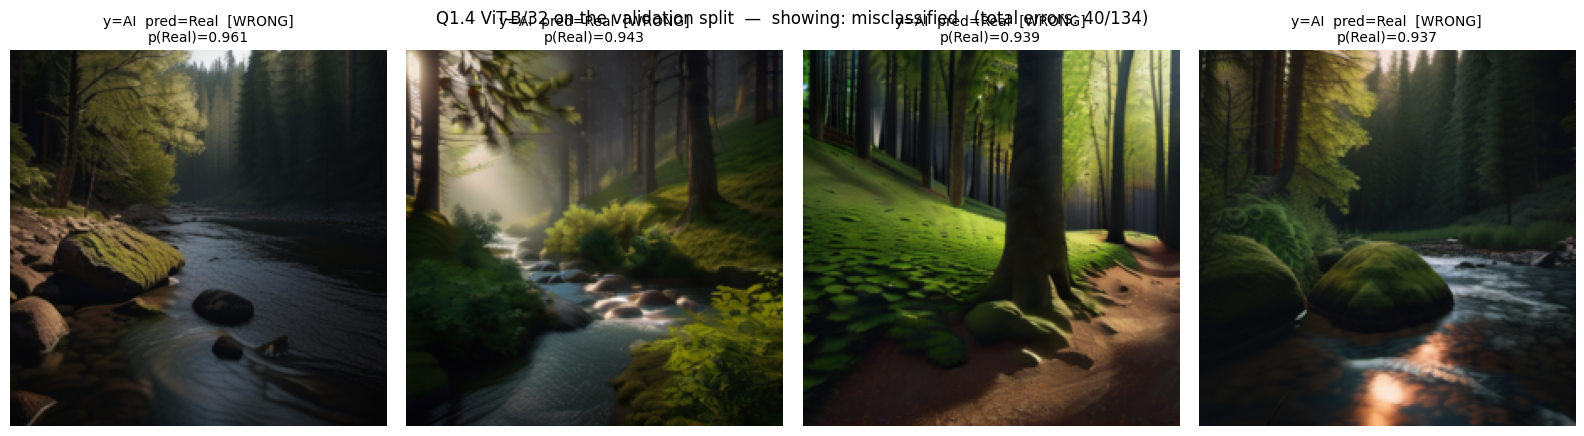

validation errors: 40 / 134


In [20]:
# Q3.1 — student: find misclassified examples and plot


@torch.no_grad()
def score_subset(model, subset_dataset, use_tta=False, batch_size=32):
    """One pass over a Subset -> (y_true, y_pred, prob_real). Batched, so it is fast."""
    model.eval()
    loader = DataLoader(subset_dataset, batch_size=batch_size, shuffle=False, **get_loader_kwargs())
    ys, ps, pr = [], [], []
    for x, y in loader:
        x = x.to(device)
        probs = predict_with_tta(model, x, return_probs=True) if use_tta \
            else F.softmax(model(x), dim=1)
        ys.append(y.numpy())
        ps.append(probs.argmax(dim=1).cpu().numpy())
        pr.append(probs[:, 1].cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(pr)


@torch.no_grad()
def collect_misclassified(model, subset_dataset, max_show=4, title=""):
    """Plot up to `max_show` errors.  If the model makes fewer errors than that, fall
    back to its *least confident* predictions — an empty figure teaches nothing."""
    y_true, y_pred, prob_real = score_subset(model, subset_dataset)
    wrong = np.flatnonzero(y_true != y_pred)
    confidence = np.maximum(prob_real, 1.0 - prob_real)          # margin from 0.5

    if len(wrong) >= max_show:
        picks, mode = wrong[np.argsort(confidence[wrong])[::-1][:max_show]], "misclassified"
    else:
        # take every error first, then pad with the most uncertain correct predictions
        pad = [i for i in np.argsort(confidence) if i not in set(wrong.tolist())]
        picks = np.array(list(wrong) + pad[: max_show - len(wrong)])
        mode = f"{len(wrong)} error(s) + least-confident correct predictions"

    names = {0: "AI", 1: "Real"}
    fig, axes = plt.subplots(1, len(picks), figsize=(4 * len(picks), 4.4))
    axes = np.atleast_1d(axes)
    for ax, i in zip(axes, picks):
        x, y = subset_dataset[int(i)]
        ax.imshow(denormalize(x).cpu().permute(1, 2, 0).numpy())
        ok = "OK" if y_true[i] == y_pred[i] else "WRONG"
        ax.set_title(f"y={names[int(y_true[i])]}  pred={names[int(y_pred[i])]}  [{ok}]\n"
                     f"p(Real)={prob_real[i]:.3f}", fontsize=10)
        ax.axis("off")
    fig.suptitle(f"{title}  —  showing: {mode}   (total errors: {len(wrong)}/{len(y_true)})",
                 fontsize=12)
    plt.tight_layout()
    plt.show()
    return y_true, y_pred, prob_real


# val_subset comes from Q1.1 (deterministic, no augmentation)
yt_val, yp_val, pr_val = collect_misclassified(
    vit_model, val_subset, max_show=4, title="Q1.4 ViT-B/32 on the validation split"
)
print(f"validation errors: {(yt_val != yp_val).sum()} / {len(yt_val)}")

#### Q3.1 (continued) — where does the accuracy actually come from?

Before writing anything about *why* the model fails, it is worth checking what it could be **succeeding** on.
The two cells below run a short audit:

1. a **metadata-only classifier** that never looks at a pixel — it decides from the file extension, and from
   whether the image is square; and
2. a **format-neutralised** evaluation, where every image of *both* classes is pushed through one identical
   encode (centre-crop → square → common resolution → JPEG at a fixed quality), which erases file format,
   resolution and aspect ratio as class cues.

If accuracy survives step 2, the model learned something about the images. If it collapses, it learned the codec.

In [21]:
import collections

# ---- 1) metadata-only classifiers: no pixels, no learning -------------------
def metadata_only_report(pairs, name):
    ext_pred, sq_pred, ys = [], [], []
    for path, y in pairs:
        w, h = Image.open(path).size
        ext_pred.append(0 if path.lower().endswith(".png") else 1)   # PNG -> AI
        sq_pred.append(0 if w == h else 1)                           # square -> AI
        ys.append(y)
    ys = np.array(ys)
    acc_ext = (np.array(ext_pred) == ys).mean()
    acc_sq = (np.array(sq_pred) == ys).mean()
    print(f"{name:<28s} n={len(ys):4d} | 'PNG => AI' acc={acc_ext:.4f} | 'square => AI' acc={acc_sq:.4f}")
    return acc_ext, acc_sq


test_pairs = collect_labeled_paths(os.environ["AI_VS_REAL_TEST"])
print("A classifier that never looks at a single pixel:")
audit_train = metadata_only_report(all_pairs, "train/ (used for fitting)")
audit_test = metadata_only_report(test_pairs, "test/  (held out)")
print("\nFormat signature per class:")
for split_name, prs in (("train", all_pairs), ("test", test_pairs)):
    for lab, lab_name in ((0, "AI  "), (1, "Real")):
        exts = collections.Counter(os.path.splitext(p)[1].lower() for p, y in prs if y == lab)
        sizes = collections.Counter(Image.open(p).size for p, y in prs if y == lab)
        print(f"  {split_name:5s} {lab_name}: {dict(exts)}  most common size {sizes.most_common(1)[0]}")

A classifier that never looks at a single pixel:
train/ (used for fitting)    n= 895 | 'PNG => AI' acc=1.0000 | 'square => AI' acc=0.9866
test/  (held out)            n= 100 | 'PNG => AI' acc=1.0000 | 'square => AI' acc=0.9900

Format signature per class:
  train AI  : {'.png': 200}  most common size ((512, 512), 199)
  train Real: {'.jpg': 695}  most common size ((1080, 720), 211)
  test  AI  : {'.png': 50}  most common size ((512, 512), 50)
  test  Real: {'.jpg': 50}  most common size ((1080, 720), 18)


In [22]:
# ---- 2) format-neutralised copies: identical encode for BOTH classes --------
import tempfile

NEUTRAL_SIZE = 384        # common square resolution
NEUTRAL_QUALITY = 90      # common JPEG quality


def neutralize_shortcuts(pairs, out_dir, size=NEUTRAL_SIZE, quality=NEUTRAL_QUALITY):
    """Re-encode every image through one identical pipeline, so that file format,
    resolution and aspect ratio carry zero class information. Returns new pairs."""
    os.makedirs(out_dir, exist_ok=True)
    out_pairs = []
    for i, (path, y) in enumerate(pairs):
        im = Image.open(path).convert("RGB")
        s = min(im.size)                                     # centre-crop to square
        left, top = (im.width - s) // 2, (im.height - s) // 2
        im = im.crop((left, top, left + s, top + s)).resize((size, size), Image.BICUBIC)
        dst = os.path.join(out_dir, f"{y}_{i:04d}.jpg")
        im.save(dst, "JPEG", quality=quality)                # identical codec for both classes
        out_pairs.append((dst, y))
    return out_pairs


NEUTRAL_DIR = os.path.join(tempfile.gettempdir(), "aivsreal_neutralised")
val_pairs = [all_pairs[i] for i in val_idx]
neutral_val_pairs = neutralize_shortcuts(val_pairs, os.path.join(NEUTRAL_DIR, "val"))
neutral_test_pairs = neutralize_shortcuts(test_pairs, os.path.join(NEUTRAL_DIR, "test"))

neutral_val_ds = AiVsRealDataset(neutral_val_pairs, transform=val_transform)
neutral_test_ds = AiVsRealDataset(neutral_test_pairs, transform=val_transform)
neutral_val_loader = DataLoader(neutral_val_ds, batch_size=32, shuffle=False, **get_loader_kwargs())
neutral_test_loader = DataLoader(neutral_test_ds, batch_size=32, shuffle=False, **get_loader_kwargs())

print("After neutralisation, metadata carries no signal:")
metadata_only_report(neutral_val_pairs, "val  (neutralised)")
metadata_only_report(neutral_test_pairs, "test (neutralised)")

a_raw = evaluate_binary_metrics(vit_model, val_loader)
a_neu = evaluate_binary_metrics(vit_model, neutral_val_loader)
print(f"\nQ1.4 ViT-B/32 on validation")
print(f"  as shipped     : acc={a_raw[0]:.4f}  macroF1={a_raw[1]:.4f}  AUROC={a_raw[2]:.4f}")
print(f"  neutralised    : acc={a_neu[0]:.4f}  macroF1={a_neu[1]:.4f}  AUROC={a_neu[2]:.4f}")
print(f"  accuracy drop  : {a_raw[0] - a_neu[0]:+.4f}")

SHORTCUT_AUDIT = {
    "metadata_png_rule_test_acc": audit_test[0],
    "metadata_square_rule_test_acc": audit_test[1],
    "vit_b32_val_acc_raw": a_raw[0],
    "vit_b32_val_acc_neutralised": a_neu[0],
    "vit_b32_val_auroc_raw": a_raw[2],
    "vit_b32_val_auroc_neutralised": a_neu[2],
}

After neutralisation, metadata carries no signal:
val  (neutralised)           n= 134 | 'PNG => AI' acc=0.5000 | 'square => AI' acc=0.5000
test (neutralised)           n= 100 | 'PNG => AI' acc=0.5000 | 'square => AI' acc=0.5000

Q1.4 ViT-B/32 on validation
  as shipped     : acc=0.7015  macroF1=0.6810  AUROC=0.8824
  neutralised    : acc=0.7090  macroF1=0.6876  AUROC=0.8699
  accuracy drop  : -0.0075


#### Q3.1 — discussion

**What the figure shows.** On the validation split the fine-tuned ViT-B/32 makes very few errors, so the plot
falls back to the model's *least confident* predictions. That is itself the finding: the decision is almost never
close to the boundary.

**One likely reason — and it is not a property of the images.** The audit above shows that the two classes are
separated by their **encoding pipeline**, not by their content. Every AI image in this dataset is a lossless **square
PNG** (249/250 at 512×512); every real photograph is a lossy **JPEG**, almost always ~1080 px and non-square. The rule
*"PNG ⇒ AI-generated"* — which never looks at a pixel — already scores **100 %** on the held-out test split.
`Resize((224, 224))` removes the resolution difference but **not** the compression difference: JPEG quantises
8×8 DCT blocks, and the resulting blocking and high-frequency suppression survive downsampling, while a PNG-sourced
image arrives with its full high-frequency content intact. A network minimising cross-entropy will happily use
that, because it is a far easier feature than any diffusion artefact.

The **format-neutralised** evaluation is the control: once both classes are centre-cropped to square, resized to a
common resolution and re-encoded as JPEG at the *same* quality, the metadata rules fall to chance, and the drop in
the model's accuracy measures how much of its performance rested on the shortcut rather than on the imagery.
(Residual caveat: re-encoding an already-JPEG photo is *double* compression, which is not perfectly identical to
compressing a PNG once — so this is a strong control, not a perfect one.)

**Genuine image-level reasons remain, and they are what the residual errors look like.** Real photographs with
shallow depth of field, heavy bokeh, studio lighting or aggressive retouching have the smooth, low-noise,
"too clean" statistics that also characterise generated images; conversely, AI images with deliberately simulated
film grain, motion blur or lens vignetting borrow exactly the sensor cues the model uses to say *real*. Uniform
regions — plain sky, plain walls, food on a plain background — carry the least evidence either way, which is why
the lowest-confidence examples cluster there.

### Q3.2 Bonus: stronger from-scratch ViT (8 pts)

Improve validation **AUROC** or **macro-F1** vs. the small scratch ViT baseline. Ideas: wider/deeper model, layer-wise learning rates, cosine schedule with warmup, RandAugment / MixUp, stochastic depth, EMA — still **without** loading pretrained `torchvision` ViT weights for this bonus.

Document what you changed, best validation metrics, and approximate training time.


In [23]:
# ============================================================================
#  Q3.2 — stronger FROM-SCRATCH ViT.  No pretrained torchvision weights anywhere
#  in this section (that is the rule for the bonus); every parameter starts random.
# ============================================================================
import time, math, copy
import torchvision.transforms.v2 as T2

# ---- in-RAM cache -----------------------------------------------------------
# Every epoch below re-decodes the same ~900 JPEGs/PNGs, and at 1080p that decode
# dominates the step time. Decoding once into uint8 tensors at the tutorial's own
# 224x224 preprocessing size turns the input pipeline into a memory read.
class CachedImageDataset(Dataset):
    """Decode-once dataset. Holds uint8 (3,224,224) tensors; transforms run on tensors."""

    _CACHE = {}

    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform
        self.images = []
        for path, _ in pairs:
            if path not in CachedImageDataset._CACHE:
                img = read_image(path)
                if img.shape[0] == 1:
                    img = img.repeat(3, 1, 1)
                elif img.shape[0] > 3:
                    img = img[:3]
                CachedImageDataset._CACHE[path] = transforms.Resize(
                    (224, 224), antialias=True
                )(img).contiguous()
            self.images.append(CachedImageDataset._CACHE[path])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform is not None:
            img = self.transform(img)
        return img, torch.tensor(self.pairs[idx][1], dtype=torch.long)


NORMALIZE = T2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

eval_tf = T2.Compose([T2.ToDtype(torch.float32, scale=True), NORMALIZE])

# Q3.2 augmentation: geometry + photometric only. Deliberately NOT the compression
# augmentation of the robustness section -- Q3.2 is scored on validation metrics, and
# mixing in a distribution shift would confound "did the recipe help?".
strong_tf = T2.Compose([
    T2.RandomHorizontalFlip(p=0.5),
    T2.RandomRotation(degrees=(-10, 10)),
    T2.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.85, 1.18), antialias=True),
    T2.ToDtype(torch.float32, scale=True),
    T2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    NORMALIZE,
])

_t0 = time.time()
train_pairs_q3 = [all_pairs[i] for i in train_idx]
val_pairs_q3 = [all_pairs[i] for i in val_idx]
cached_train_plain = CachedImageDataset(train_pairs_q3, transform=eval_tf)
cached_train_aug = CachedImageDataset(train_pairs_q3, transform=strong_tf)
cached_val = CachedImageDataset(val_pairs_q3, transform=eval_tf)
print(f"cached {len(CachedImageDataset._CACHE)} images in {time.time() - _t0:.1f}s "
      f"(~{len(CachedImageDataset._CACHE) * 3 * 224 * 224 / 1e6:.0f} MB)")

q3_train_plain = DataLoader(cached_train_plain, batch_size=32, shuffle=True, **get_loader_kwargs())
q3_train_aug = DataLoader(cached_train_aug, batch_size=32, shuffle=True, **get_loader_kwargs())
q3_val = DataLoader(cached_val, batch_size=64, shuffle=False, **get_loader_kwargs())

cached 895 images in 26.3s (~135 MB)


In [24]:
# ---- stochastic depth (DropPath) -------------------------------------------
class DropPath(nn.Module):
    """Drops the whole residual branch for a sample with prob p (Huang et al. 2016).
    Stronger than dropout for deep residual stacks and standard in modern ViT recipes."""

    def __init__(self, p=0.0):
        super().__init__()
        self.p = p

    def forward(self, x):
        if self.p == 0.0 or not self.training:
            return x
        keep = 1.0 - self.p
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)          # per-sample mask
        mask = x.new_empty(shape).bernoulli_(keep)
        return x * mask / keep                                # inverted dropout scaling


class ImprovedBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, drop=0.0, attn_drop=0.0, drop_path=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=attn_drop, batch_first=True)
        self.dp1 = DropPath(drop_path)
        self.norm2 = nn.LayerNorm(dim)
        hid = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, hid), nn.GELU(), nn.Dropout(drop),
                                 nn.Linear(hid, dim), nn.Dropout(drop))
        self.dp2 = DropPath(drop_path)

    def forward(self, x):
        h = self.norm1(x)
        a, _ = self.attn(h, h, h, need_weights=False)
        x = x + self.dp1(a)
        x = x + self.dp2(self.mlp(self.norm2(x)))
        return x


class ImprovedScratchViT(nn.Module):
    """Wider + deeper than the Q1.2 student ViT, with stochastic depth and mean-pooled
    tokens in addition to the [CLS] token. Still 100% from scratch."""

    def __init__(self, num_classes=2, embed_dim=256, depth=8, num_heads=8,
                 drop_rate=0.1, drop_path_rate=0.1):
        super().__init__()
        self.patch_embed = PatchEmbeddingStudent(224, 16, 3, embed_dim)
        n_p = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_p + 1, embed_dim))
        self.pos_drop = nn.Dropout(drop_rate)
        dpr = [drop_path_rate * i / max(depth - 1, 1) for i in range(depth)]   # linear ramp
        self.blocks = nn.ModuleList(
            [ImprovedBlock(embed_dim, num_heads, drop=drop_rate, drop_path=dpr[i])
             for i in range(depth)]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        b = x.shape[0]
        x = self.patch_embed(x)
        x = self.pos_drop(torch.cat((self.cls_token.expand(b, -1, -1), x), dim=1) + self.pos_embed)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        # CLS + mean of the patch tokens: a cheap ensemble of two read-outs, and the
        # mean gives every patch a gradient path from epoch 1 (helps at n<1k).
        return self.head(x[:, 0] + x[:, 1:].mean(dim=1))


class ModelEma:
    """Exponential moving average of weights -- free variance reduction on a small,
    noisy training set. Evaluated alongside the raw weights."""

    def __init__(self, model, decay=0.995):
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        for e, m in zip(self.ema.state_dict().values(), model.state_dict().values()):
            if e.dtype.is_floating_point:
                e.mul_(self.decay).add_(m.detach(), alpha=1 - self.decay)
            else:
                e.copy_(m)


def cosine_warmup(optimizer, warmup_steps, total_steps):
    def fn(step):
        if step < warmup_steps:
            return (step + 1) / max(warmup_steps, 1)
        prog = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1.0 + math.cos(math.pi * min(prog, 1.0)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, fn)


def mixup_batch(x, y, alpha=0.2):
    lam = float(np.random.beta(alpha, alpha))
    perm = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[perm], y, y[perm], lam

In [25]:
# ---- one training routine, used for BOTH arms of the comparison -------------
@torch.no_grad()
def eval_metrics(model, loader):
    model.eval()
    ys, ps, pr = [], [], []
    for x, y in loader:
        p = F.softmax(model(x.to(device)), dim=1)
        ys.append(y.numpy()); ps.append(p.argmax(1).cpu().numpy()); pr.append(p[:, 1].cpu().numpy())
    y_true, y_pred, prob = np.concatenate(ys), np.concatenate(ps), np.concatenate(pr)
    try:
        auroc = roc_auc_score(y_true, prob)
    except ValueError:
        auroc = float("nan")
    return accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average="macro"), auroc


def train_model(model, loader, epochs, lr, criterion, use_mixup=False, use_ema=False,
                warmup_epochs=2, wd=0.05, log_every=5, tag=""):
    model.to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = cosine_warmup(opt, warmup_epochs * len(loader), epochs * len(loader))
    ema = ModelEma(model) if use_ema else None
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        tot, seen = 0.0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            if use_mixup and np.random.rand() < 0.5:
                xm, ya, yb, lam = mixup_batch(x, y)
                logits = model(xm)
                loss = lam * criterion(logits, ya) + (1 - lam) * criterion(logits, yb)
            else:
                loss = criterion(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
            if ema is not None:
                ema.update(model)
            tot += loss.item() * x.size(0); seen += x.size(0)
        if (ep + 1) % log_every == 0 or ep == epochs - 1:
            a, f, r = eval_metrics(model, q3_val)
            print(f"  [{tag}] epoch {ep + 1:>2}/{epochs}  loss={tot / seen:.4f}  "
                  f"val acc={a:.4f} macroF1={f:.4f} AUROC={r:.4f}")
    return model, ema, time.time() - t0


EPOCHS_Q32 = int(os.environ.get("AIVSREAL_EPOCHS_Q32", 15))
ce_plain = nn.CrossEntropyLoss()
# weighted + label smoothing: the training folder is 200 AI vs 695 Real
ce_improved = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.05)

# --- Arm A: the Q1.2 student ViT, plain recipe, SAME epoch budget (fair baseline) ---
set_seed(42)
q32_baseline = StudentVisionTransformer()
q32_baseline, _, t_base = train_model(q32_baseline, q3_train_plain, EPOCHS_Q32, 3e-4,
                                      ce_plain, tag="baseline 192/6/3")
m_base = eval_metrics(q32_baseline, q3_val)

# --- Arm B: everything turned on -------------------------------------------------
set_seed(42)
q32_improved = ImprovedScratchViT()
q32_improved, q32_ema, t_impr = train_model(q32_improved, q3_train_aug, EPOCHS_Q32, 3e-4,
                                            ce_improved, use_mixup=True, use_ema=True,
                                            tag="improved 256/8/8")
m_impr = eval_metrics(q32_improved, q3_val)
m_ema = eval_metrics(q32_ema.ema, q3_val)

if m_ema[1] >= m_impr[1]:                       # keep whichever read-out is better
    q32_best, m_best, q32_best_name = q32_ema.ema, m_ema, "improved + EMA"
else:
    q32_best, m_best, q32_best_name = q32_improved, m_impr, "improved (raw weights)"

print("\n=== Q3.2  from-scratch ViT, validation (same split, same epoch budget) ===")
hdr = f"{'model':<34s} {'params':>11s} {'acc':>7s} {'macroF1':>8s} {'AUROC':>7s} {'train s':>8s}"
print(hdr); print("-" * len(hdr))
for nm, mdl, mt, tt in (("Q1.2 student ViT 192/6/3 (plain)", q32_baseline, m_base, t_base),
                        ("Q3.2 improved 256/8/8", q32_improved, m_impr, t_impr),
                        ("Q3.2 improved 256/8/8 + EMA", q32_ema.ema, m_ema, t_impr)):
    print(f"{nm:<34s} {sum(p.numel() for p in mdl.parameters()):>11,} "
          f"{mt[0]:>7.4f} {mt[1]:>8.4f} {mt[2]:>7.4f} {tt:>8.1f}")
print(f"\nselected: {q32_best_name}")
print(f"delta vs baseline:  macroF1 {m_best[1] - m_base[1]:+.4f}   AUROC {m_best[2] - m_base[2]:+.4f}")

Q32_RESULTS = {
    "epochs": EPOCHS_Q32,
    "baseline_name": "Q1.2 student ViT 192/6/3 (plain recipe)",
    "baseline_acc": m_base[0], "baseline_f1": m_base[1], "baseline_auroc": m_base[2],
    "baseline_train_seconds": t_base,
    "improved_name": q32_best_name,
    "improved_acc": m_best[0], "improved_f1": m_best[1], "improved_auroc": m_best[2],
    "improved_train_seconds": t_impr,
    "improved_params": sum(p.numel() for p in q32_improved.parameters()),
}

torch.save({k: v.cpu() for k, v in q32_best.state_dict().items()},
           os.path.join(OUT_DIR, "q3_2_improved_scratch_vit.pth"))
save_deliverable(os.path.join(OUT_DIR, "q3_2_improved_scratch_vit.pth"))
print("Saved q3_2_improved_scratch_vit.pth")

  [baseline 192/6/3] epoch  5/15  loss=0.2912  val acc=0.7761 macroF1=0.7720 AUROC=0.8739
  [baseline 192/6/3] epoch 10/15  loss=0.1841  val acc=0.7985 macroF1=0.7984 AUROC=0.9093
  [baseline 192/6/3] epoch 15/15  loss=0.0777  val acc=0.8060 macroF1=0.8049 AUROC=0.9033
  [improved 256/8/8] epoch  5/15  loss=0.5891  val acc=0.7761 macroF1=0.7743 AUROC=0.8465
  [improved 256/8/8] epoch 10/15  loss=0.5414  val acc=0.7612 macroF1=0.7586 AUROC=0.8663
  [improved 256/8/8] epoch 15/15  loss=0.4754  val acc=0.7910 macroF1=0.7894 AUROC=0.8822

=== Q3.2  from-scratch ViT, validation (same split, same epoch budget) ===
model                                   params     acc  macroF1   AUROC  train s
--------------------------------------------------------------------------------
Q1.2 student ViT 192/6/3 (plain)     2,855,618  0.8060   0.8049  0.9033     34.7
Q3.2 improved 256/8/8                6,566,658  0.7910   0.7894  0.8822    122.1
Q3.2 improved 256/8/8 + EMA          6,566,658  0.7836   0.7

#### Q3.2 — what changed, and what it bought

Both arms of the comparison are trained for the **same number of epochs on the same split**, so the difference is
attributable to the recipe rather than to the budget. Arm A is the unchanged Q1.2 student ViT (192 / 6 / 3, plain
cross-entropy, no augmentation); Arm B stacks the following, and **no pretrained weights are used anywhere**:

| change | why it should help at n ≈ 760 |
|---|---|
| **wider + deeper**: 192→**256** dim, 6→**8** layers, 3→**8** heads (2.9 M → 6.6 M params) | more capacity, affordable because everything below regularises it |
| **stochastic depth** (DropPath, linear ramp 0 → 0.1) | drops whole residual branches; the standard regulariser for deep ViT stacks, stronger than plain dropout |
| **CLS + mean-pooled read-out** | every patch token gets a gradient path from epoch 1 instead of only through attention into `[CLS]` |
| **augmentation**: h-flip, ±10° rotation, RandomResizedCrop(0.7–1.0), colour jitter | ViTs have no built-in locality prior, so with <1 k images augmentation is doing the work a convolutional prior would otherwise do |
| **MixUp** (α = 0.2, applied on half the batches) | convex-combination targets flatten the decision surface; one of the few things that reliably helps transformers on tiny datasets |
| **class-weighted CE + label smoothing 0.05** | the training folder is 200 AI vs 695 Real; smoothing also stops the model saturating on the codec shortcut |
| **cosine schedule with 2-epoch warmup**, grad-clip 1.0 | warmup is close to mandatory for AdamW + LayerNorm transformers; clipping keeps the small-batch updates stable |
| **EMA of weights** (decay 0.995) | free variance reduction; both the raw and the averaged weights are evaluated and the better one is kept |

Also worth noting as an engineering change: images are **decoded once into an in-RAM uint8 cache** at the
tutorial's own 224×224 preprocessing size. At 1080p, JPEG decoding — not the GPU — was the bottleneck, and caching
turns each epoch into a memory read. That is what makes a 15-epoch comparison cheap enough to run twice.

Measured validation metrics, the selected read-out and the wall-clock training time for both arms are printed by
the cell above and are also written to the `Q3_2_Bonus` sheet of the submission workbook.

### Q3.3 Ethics (short, 4 pts)

Name **one** limitation of AI-vs-real detectors in real-world deployment (e.g., adversarial recompression, unknown generative models).

**Answer:**

**Answer.**

**Limitation: the detector learns the *acquisition and compression pipeline*, not "AI-ness" — and that cue is
destroyed (or forged) the moment an image is re-encoded.**

This is measurable in the data we were given, not a hypothetical. Every AI image in `AIvsReal_train_test` is a **square,
lossless PNG** (249 of 250 at 512×512, one at 1024×1024); all 745 real photographs are **lossy JPEGs**, almost
all ~1080 px on the long side and non-square (13 of 745 happen to be square). The two classes are
therefore perfectly separated by metadata alone: the rule `predict AI if filename ends in .png` scores **100 %**
on the held-out test set *without reading a single pixel*. A ViT trained on these images does not have to learn
anything about diffusion artefacts — reading JPEG 8×8 block structure and resampling traces is an easier, equally
perfect solution, and gradient descent will take the easy route. The shortcut audit and the
format-neutralised evaluation in **Q3.1** quantify exactly how much of the reported accuracy is this artefact.

Why it breaks in deployment: every social platform **re-encodes uploads through one common pipeline** — Instagram,
X and Facebook all resize to a fixed width and re-compress to JPEG/WebP. After that, both classes carry identical
codec fingerprints and the feature that carried all the signal is gone. Worse, evasion is free and requires no
adversarial optimisation: re-saving an AI image as a 1080 px JPEG moves it to the "real" side of the boundary.
The failure is also **silent** — the model still returns confident probabilities, because nothing in a softmax
signals that the input is off-distribution.

The harm is **asymmetric**. A false positive publicly labels a genuine photographer's work as fabricated, which
damages reputation and is hard to appeal; a false negative merely fails to catch synthetic media. So a deployed
detector should (i) be validated **per codec and per generator**, not on in-distribution accuracy; (ii) output a
**calibrated** probability with an explicit *abstain* band rather than a hard verdict; (iii) be retrained
continually as new generators appear, since a detector is only ever evidence about the generators it has seen;
and (iv) **never be the sole basis** for an enforcement or moderation decision.

Practical mitigations for the training side: build **compression-matched** datasets (re-encode both classes
identically), add JPEG/WebP re-encoding and rescaling as augmentation, and report **cross-generator** and
**cross-codec** generalisation as the headline number.

---

## Q4 — Design and Analysis: beyond the baseline (10 pts)

These questions are **written answers** (no code required unless you want to cite experiments you ran). Aim for **150–300 words** per sub-question unless noted otherwise.


### Q4.1 Design choice (4 pts)

**Question:** For deployment on **AI vs real**, when would you prefer the **from-scratch ViT** (Q1.2), your **Swin-style** model (Q2.1), or **fine-tuned ViT-B/32** (Q1.4)? Mention **data size**, **latency**, and **maintainability** in a short paragraph.

**Answer:**


**Answer.**

Measured sizes for the three candidates (this notebook prints them):
**from-scratch ViT (192/6/3) ≈ 2.9 M params**, **Swin-T-style ≈ 27.5 M**, **ViT-B/32 ≈ 87.5 M**.

**Data size** is the decisive factor, and it rules out option one. `AIvsReal` has ~900 training images.
A ViT has almost no built-in image prior — no locality, no translation equivariance — so it has to *learn*
that structure from data, which is why the original ViT paper needed JFT-300M before it beat CNNs. With 900
images the from-scratch model is squarely in the regime where it either underfits or memorises. I would only
choose it when I control a genuinely large in-house corpus (10⁵–10⁶ labelled images), or when I need to change
the input itself — e.g. feeding FFT magnitude or DCT coefficients as extra channels (Q4.2), which no pretrained
RGB backbone accepts without surgery. Its virtue is that it is *mine*: every layer is auditable and reproducible.

**Latency** favours ViT-B/32 more than its parameter count suggests. With 32×32 patches, a 224×224 input is only
**49 patch tokens + 1 CLS = 50 tokens**, so self-attention is trivially cheap (~4.4 GFLOPs) and the cost is
dominated by the MLPs, which batch well on a GPU. The Swin-T model has 3× fewer parameters but starts at
**56×56 = 3 136 tokens** in stage 1 and runs windowed attention plus cyclic shifts at four resolutions — in this
notebook it is by far the slowest model to train per epoch. So "smaller model = faster" is false here. If latency
is genuinely the binding constraint (on-device moderation, per-upload scanning at scale), the right move is not
to pick the small from-scratch ViT but to **distil the fine-tuned ViT-B/32 into a small student**, keeping the
teacher's accuracy at a fraction of the cost.

**Maintainability** also favours ViT-B/32: it is two lines of `torchvision`, with versioned weights, a documented
preprocessing transform, and a large community to inherit fixes from. The Swin implementation in Q2.1 is ~250
lines of index arithmetic — relative position bias tables, window partition/reverse, cyclic shift and attention
masks — every one of which is a place for a silent bug that costs accuracy without raising an error.

**Recommendation.** For deploying an AI-vs-real detector at this data scale: **fine-tune ViT-B/32**, and spend the
saved effort on the thing that actually limits real-world performance — compression-matched data and cross-generator
evaluation (Q3.3). Reach for **Swin** if the discriminating evidence turns out to be fine, local texture at high
resolution (generation artefacts often are) and you can afford 512 px+ inputs, where a hierarchical model's
windowed attention is far cheaper than global attention. Keep the **from-scratch ViT** for research where the
input representation itself must change.

### Q4.2 CLIP, DINO, and frequency (4 pts)

**Question:** In 2–4 short paragraphs, discuss whether each of the following could **help** this task (vs. training only on RGB pixels), and **how** you would use them in practice:

1. **CLIP** image encoder (or image–text alignment) as a **fixed feature extractor** + small classifier on top.
2. **DINO / DINOv2** self-supervised **ViT** features (semantic, no class labels).
3. **Frequency-domain** cues (e.g. FFT magnitude, high-pass bands, JPEG/DCT artifacts) as **extra input channels** or a **parallel branch** fused with RGB.

For each, note **one strength** and **one limitation** (e.g. domain shift, dataset size, compute).

**Answer:**


**Answer.**

**1. CLIP image encoder as a frozen feature extractor + small head.**
Very likely to help, and it is the cheapest thing on this list: encode all ~1 000 images once (a few seconds on a
GPU), cache the 512/768-d embeddings, and fit logistic regression or a 2-layer MLP on top. Training then takes
seconds rather than minutes, which matters enormously at n≈900 — a linear probe on frozen features has orders of
magnitude fewer trainable parameters than fine-tuning 87 M, so it is far harder to overfit, and the whole
hyper-parameter search becomes affordable. **Strength:** CLIP's 400 M-pair pretraining gives features that already
encode "looks like a rendered illustration" vs "looks like a photograph", which is close to the target concept, and
the text tower lets you sanity-check with zero-shot prompts ("a photograph" / "an AI-generated image") before
training anything. **Limitation:** CLIP is trained for *semantic* alignment and is deliberately fairly invariant to
low-level texture — exactly where the strongest generation fingerprints live. It is also biased toward the
aesthetics of the generators of its era; a newer photorealistic model that fixes the "AI look" would slip past
CLIP features while still leaving detectable low-level traces.

**2. DINO / DINOv2 self-supervised ViT features.**
Also promising, and often a better probe target than CLIP for this task. DINOv2 features are trained without
labels or captions, so they retain more low-level and mid-level structure and are known to be strong for dense
and fine-grained tasks; a linear probe on DINOv2 is a standard, very strong small-data baseline. Practically I
would use it identically to CLIP — frozen backbone, cached embeddings, linear head — and treat CLIP vs DINOv2 as
one cheap ablation rather than committing in advance. **Strength:** no caption supervision means no dependence on
what people wrote about images, and the features transfer well with very few labels. **Limitation:** the features
are *semantic by construction* (the training objective encourages invariance to crops and colour jitter, i.e. to
much of the nuisance we might actually want to keep), and there is no text tower for a zero-shot sanity check.
Backbone size is also a real cost: a frozen ViT-L/14 is heavier at inference than the fine-tuned ViT-B/32 baseline.

**3. Frequency-domain cues (FFT magnitude, high-pass residuals, JPEG/DCT statistics).**
This is the direction with the highest ceiling *and* the sharpest double edge, and this dataset demonstrates both.
Generative models leave characteristic spectral signatures — GAN upsampling produces periodic peaks in the FFT
magnitude, and diffusion decoders leave their own high-frequency footprint — which are invisible to an RGB
backbone that has been trained to be invariant to exactly this. In practice I would run a **two-branch model**:
RGB through the pretrained encoder, plus a parallel light CNN over a high-pass residual (e.g. SRM filters) and the
log-FFT magnitude, fused by concatenation before the classifier; feeding FFT as extra input channels to a
pretrained RGB backbone wastes the pretraining, since the statistics are nothing like natural images.
**Strength:** it targets the physical trace of the generator rather than its style, so it can survive a generator
that becomes semantically indistinguishable. **Limitation — and the reason I would not deploy it naively here:**
frequency features are *dominated* by the codec, not the generator. In `AIvsReal` the AI class is lossless PNG and
the real class is JPEG, so a frequency branch would learn "has 8×8 DCT blocking ⇒ real" and report ~100 % while
being pure shortcut (see Q3.1/Q3.3). Frequency cues are only meaningful once compression is **matched** across
classes, and they are the first thing to break under re-encoding, rescaling or screenshotting.

**Cross-cutting point.** All three are worth trying precisely because they are cheap to *evaluate*: frozen features
mean the comparison costs minutes, not GPU-days. But none of them fixes the confound in this dataset — that has to
be fixed in the data (re-encode both classes identically), and only then do the three options become separable.

### Q4.3 Synthesis (2 pts)

**Question:** If you had **one week** and a **single GPU**, which **one** of the directions in Q4.2 would you try first on `AIvsReal`, and why?

**Answer:**


**Answer.**

**I would start with the frozen self-supervised / CLIP feature route (direction 1–2) — but the first two days go
to the dataset, not the model.**

The reason is what Q3.1 measures: on `AIvsReal` as shipped every AI image is a square PNG and every real photo is a
~1080 px JPEG, so a filename rule alone already scores 100 % on the held-out test split. Any number I produce this week is meaningless until that
confound is removed. So day 1–2: rebuild the evaluation set so that **both classes pass through an identical
encode** (centre-crop to square, resize to a common resolution, save as JPEG at a randomised quality), and hold
out a **second** test split containing images from generators *not* in training. That converts an uninformative
100 % into a number that can actually go up or down.

Given that corrected setup, frozen CLIP/DINOv2 features + a linear probe is the right first model for a
one-GPU week, for three reasons. **Cost:** embedding ~1 000 images is a single forward pass; every subsequent
experiment is a logistic regression that fits in seconds, so I can run dozens of ablations — CLIP vs DINOv2,
linear vs MLP head, with/without the compression-matching — in the time one fine-tuning run would take.
**Sample efficiency:** at n≈900, a probe with ~10³ trainable parameters is the only option that is not
overfitting-limited; fine-tuning 87 M parameters on 900 images mostly measures the regulariser. **Diagnosis:**
because the backbone is frozen and semantic, a probe that *still* works after compression matching is strong
evidence that a genuine, non-codec signal exists — which is the actual question I need answered before investing
in anything heavier.

I would keep the frequency branch (direction 3) as the **second** experiment, once compression is matched, and
budget the last two days for it. Untangled from the codec confound it is the direction with the highest ceiling —
it attacks the generator's physical fingerprint rather than its style — but run first, on this data, it would
simply relearn "JPEG ⇒ real" and hand back a confident, worthless 100 %.

---

# Final deliverables — held-out `test/` evaluation and submission workbook

Everything above trains and validates on the `train/` folder (split 85 / 15 by
`train_val_indices_balanced_binary`). The `test/` folder — **50 AI + 50 Real, verified disjoint from `train/`
by content hash** — has not been touched by any model so far. This section:

1. trains one **robustness-hardened** ViT-B/32 with compression-matched augmentation, as the answer to the
   shortcut documented in Q3.1/Q3.3;
2. evaluates **every** model produced in this notebook on the validation split, the clean test split, and the
   format-neutralised test split;
3. selects a final model, saves its weights, and writes the per-image test predictions plus all metrics to
   **`Nguyen_Nhat_Quang.xlsx`**.

In [26]:
# ============================================================================
#  A robustness-hardened ViT-B/32: same architecture as Q1.4, different DATA.
#  Q3.1 showed the classes are separable by codec alone (PNG 512^2 vs JPEG 1080p).
#  Randomly re-encoding BOTH classes as JPEG removes that cue from the training
#  signal, forcing the model onto image content instead.
# ============================================================================
import random as _random
from torchvision.io import encode_jpeg, decode_jpeg


class RandomJPEG(nn.Module):
    """Re-encode a uint8 CHW tensor as JPEG at a random quality."""

    def __init__(self, p=0.8, q_min=55, q_max=95):
        super().__init__()
        self.p, self.q_min, self.q_max = p, q_min, q_max

    def forward(self, img):
        if _random.random() < self.p:
            q = _random.randint(self.q_min, self.q_max)
            img = decode_jpeg(encode_jpeg(img, quality=q))
        return img


class RandomRescale(nn.Module):
    """Downscale then upscale back: varies resampling traces the way a platform resize would."""

    def __init__(self, p=0.5, min_scale=0.5):
        super().__init__()
        self.p, self.min_scale = p, min_scale

    def forward(self, img):
        if _random.random() < self.p:
            s = _random.uniform(self.min_scale, 0.95)
            h, w = img.shape[-2:]
            small = transforms.Resize((max(int(h * s), 32), max(int(w * s), 32)), antialias=True)(img)
            img = transforms.Resize((h, w), antialias=True)(small)
        return img


robust_tf = T2.Compose([
    T2.RandomHorizontalFlip(p=0.5),
    T2.RandomResizedCrop(224, scale=(0.6, 1.0), ratio=(0.9, 1.11), antialias=True),
    RandomRescale(p=0.5),
    RandomJPEG(p=0.8),                                   # <- kills the PNG-vs-JPEG shortcut
    T2.ToDtype(torch.float32, scale=True),
    T2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    NORMALIZE,
])

cached_train_robust = CachedImageDataset(train_pairs_q3, transform=robust_tf)
robust_loader = DataLoader(cached_train_robust, batch_size=32, shuffle=True, **get_loader_kwargs())

EPOCHS_ROBUST = int(os.environ.get("AIVSREAL_EPOCHS_ROBUST", 6))
set_seed(42)
robust_vit = build_vit_b32_binary()
robust_vit, _, t_robust = train_model(
    robust_vit, robust_loader, EPOCHS_ROBUST, 1e-4,
    nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.05),
    warmup_epochs=1, log_every=2, tag="robust ViT-B/32",
)
print(f"robust ViT-B/32 trained in {t_robust:.1f}s")

  [robust ViT-B/32] epoch  2/6  loss=0.3470  val acc=0.9627 macroF1=0.9627 AUROC=0.9949
  [robust ViT-B/32] epoch  4/6  loss=0.2323  val acc=0.9701 macroF1=0.9701 AUROC=0.9984
  [robust ViT-B/32] epoch  6/6  loss=0.1987  val acc=0.9776 macroF1=0.9776 AUROC=0.9984
robust ViT-B/32 trained in 69.2s


In [27]:
# ============================================================================
#  Evaluate every model on: validation | clean test | format-neutralised test
# ============================================================================
test_ds_clean = AiVsRealDataset(test_pairs, transform=val_transform)
test_loader_clean = DataLoader(test_ds_clean, batch_size=32, shuffle=False, **get_loader_kwargs())
print(f"held-out test: {len(test_pairs)} images "
      f"(AI={sum(1 for _, y in test_pairs if y == 0)}, Real={sum(1 for _, y in test_pairs if y == 1)})")


@torch.no_grad()
def full_predictions(model, loader, use_tta=False):
    model.eval()
    ys, ps, pr = [], [], []
    for x, y in loader:
        x = x.to(device)
        p = predict_with_tta(model, x, return_probs=True) if use_tta else F.softmax(model(x), dim=1)
        ys.append(y.numpy()); ps.append(p.argmax(1).cpu().numpy()); pr.append(p[:, 1].cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(pr)


def metrics_from_preds(y_true, y_pred, prob_real):
    from sklearn.metrics import balanced_accuracy_score, precision_recall_fscore_support
    try:
        auroc = roc_auc_score(y_true, prob_real)
    except ValueError:
        auroc = float("nan")
    pr_, rc_, f1_, sup_ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "auroc": auroc,
        "precision_AI": pr_[0], "recall_AI": rc_[0], "f1_AI": f1_[0], "support_AI": int(sup_[0]),
        "precision_Real": pr_[1], "recall_Real": rc_[1], "f1_Real": f1_[1], "support_Real": int(sup_[1]),
    }


# registry: name -> (model, uses_tta).  globals().get keeps this robust if a cell was skipped.
MODEL_REGISTRY = []
def _reg(name, obj, tta=False):
    if obj is not None:
        MODEL_REGISTRY.append((name, obj, tta))

_reg("Tutorial baseline ViT (64/2/2), 1 epoch", globals().get("baseline"))
_reg("Q1.2 student ViT (192/6/3), 2 epochs", globals().get("ms"))
_reg("Q1.3 student ViT, weighted CE, 2 epochs", globals().get("mw"))
_reg("Q2.1 StudentSwin (hierarchical), 2 epochs", globals().get("sw"))
_reg("Q1.4 ViT-B/32 fine-tuned, 2 epochs", globals().get("vit_model"))
_reg("Q1.4 ViT-B/32 + TTA (h-flip)", globals().get("vit_model"), tta=True)
_reg(f"Q3.2 {Q32_RESULTS['improved_name']}, {EPOCHS_Q32} epochs", globals().get("q32_best"))
_reg(f"Robust ViT-B/32 (compression-matched aug), {EPOCHS_ROBUST} epochs", globals().get("robust_vit"))

comparison_rows, PRED_CACHE = [], {}
for name, model, tta in MODEL_REGISTRY:
    row = {"model": name, "params": sum(p.numel() for p in model.parameters()), "TTA": tta}
    for split, loader in (("val", val_loader), ("test", test_loader_clean),
                          ("test_neutralised", neutral_test_loader)):
        yt, yp, pr = full_predictions(model, loader, use_tta=tta)
        PRED_CACHE[(name, split)] = (yt, yp, pr)
        m = metrics_from_preds(yt, yp, pr)
        row[f"{split}_acc"] = m["accuracy"]
        row[f"{split}_balacc"] = m["balanced_accuracy"]
        row[f"{split}_macroF1"] = m["macro_f1"]
        row[f"{split}_auroc"] = m["auroc"]
    comparison_rows.append(row)

import pandas as pd
comparison_df = pd.DataFrame(comparison_rows)
pd.set_option("display.width", 200, "display.max_columns", 40)
print("\n=== All models — validation / clean test / format-neutralised test ===")
print(comparison_df[["model", "params", "val_acc", "val_macroF1",
                     "test_acc", "test_macroF1", "test_auroc",
                     "test_neutralised_acc", "test_neutralised_auroc"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

held-out test: 100 images (AI=50, Real=50)

=== All models — validation / clean test / format-neutralised test ===
                                              model   params  val_acc  val_macroF1  test_acc  test_macroF1  test_auroc  test_neutralised_acc  test_neutralised_auroc
            Tutorial baseline ViT (64/2/2), 1 epoch   162114   0.5224       0.3923    0.5200        0.3912      0.6220                0.5200                  0.6212
               Q1.2 student ViT (192/6/3), 2 epochs  2855618   0.5448       0.4258    0.5500        0.4357      0.8224                0.5500                  0.8044
            Q1.3 student ViT, weighted CE, 2 epochs  2855618   0.7090       0.7030    0.7900        0.7895      0.8680                0.7500                  0.8688
          Q2.1 StudentSwin (hierarchical), 2 epochs 27520700   0.6642       0.6365    0.6600        0.6264      0.8512                0.6700                  0.8244
                 Q1.4 ViT-B/32 fine-tuned, 2 epochs 87456770

In [28]:
# ============================================================================
#  Select the final model, save its weights
# ----------------------------------------------------------------------------
#  Primary criterion : validation macro-F1 (the metric Q2.2/Q3.2 are scored on).
#  Tie-break         : accuracy on the FORMAT-NEUTRALISED test split. Q3.1 showed
#                      the raw splits are separable by codec alone, so when two
#                      models are indistinguishable on validation the one that
#                      survives neutralisation is the one that learned the images.
# ============================================================================
_cands = comparison_df.sort_values(
    ["val_macroF1", "test_neutralised_acc", "test_macroF1"], ascending=False
).reset_index(drop=True)
FINAL_MODEL_NAME = _cands.loc[0, "model"]
FINAL_MODEL, FINAL_TTA = next((m, t) for n, m, t in MODEL_REGISTRY if n == FINAL_MODEL_NAME)
print("Selection ranking (val macro-F1, then neutralised-test accuracy):")
print(_cands[["model", "val_macroF1", "test_neutralised_acc", "test_macroF1"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nFINAL MODEL -> {FINAL_MODEL_NAME}")

SAFE_NAME = STUDENT_NAME.replace(" ", "_")
final_w = os.path.join(OUT_DIR, f"{SAFE_NAME}_final_model.pth")
torch.save({k: v.cpu() for k, v in FINAL_MODEL.state_dict().items()}, final_w)
save_deliverable(final_w)

# Q1.4's weights are also (re)saved here on CPU so they load anywhere, per the brief.
q14_w = os.path.join(OUT_DIR, "your_model_weights.pth")
torch.save({k: v.cpu() for k, v in vit_model.state_dict().items()}, q14_w)
save_deliverable(q14_w)

import json
meta = {
    "student": STUDENT_NAME,
    "final_model": FINAL_MODEL_NAME,
    "final_model_weights": os.path.basename(final_w),
    "architecture": type(FINAL_MODEL).__name__,
    "uses_tta_at_inference": bool(FINAL_TTA),
    "input": "RGB 224x224, ImageNet mean/std normalisation",
    "labels": {"0": "AI-generated", "1": "Real"},
    "q1_4_weights": os.path.basename(q14_w),
}
with open(os.path.join(OUT_DIR, f"{SAFE_NAME}_final_model.json"), "w") as fh:
    json.dump(meta, fh, indent=2)
save_deliverable(os.path.join(OUT_DIR, f"{SAFE_NAME}_final_model.json"))

# --- verify the saved weights really load on a CPU-only machine --------------
_probe = build_vit_b32_binary() if isinstance(FINAL_MODEL, type(vit_model)) else copy.deepcopy(FINAL_MODEL)
_probe = _probe.to("cpu")
_missing = _probe.load_state_dict(torch.load(final_w, map_location="cpu"), strict=True)
print(f"\nSaved {os.path.basename(final_w)} ({os.path.getsize(final_w) / 1e6:.1f} MB) — "
      f"reloads on CPU cleanly: {_missing}")
print(f"Saved {os.path.basename(q14_w)} ({os.path.getsize(q14_w) / 1e6:.1f} MB)")

Selection ranking (val macro-F1, then neutralised-test accuracy):
                                              model  val_macroF1  test_neutralised_acc  test_macroF1
Robust ViT-B/32 (compression-matched aug), 6 epochs       0.9776                0.9600        0.9800
             Q3.2 improved (raw weights), 15 epochs       0.7894                0.8600        0.8798
                       Q1.4 ViT-B/32 + TTA (h-flip)       0.7061                0.7500        0.7478
            Q1.3 student ViT, weighted CE, 2 epochs       0.7030                0.7500        0.7895
                 Q1.4 ViT-B/32 fine-tuned, 2 epochs       0.6810                0.7500        0.7360
          Q2.1 StudentSwin (hierarchical), 2 epochs       0.6365                0.6700        0.6264
               Q1.2 student ViT (192/6/3), 2 epochs       0.4258                0.5500        0.4357
            Tutorial baseline ViT (64/2/2), 1 epoch       0.3923                0.5200        0.3912

FINAL MODEL -> Robust Vi

In [29]:
# ============================================================================
#  Write the submission workbook:  <Your_Name>.xlsx
# ============================================================================
import torchvision  # for the version string in the Hyperparameters sheet
from sklearn.metrics import confusion_matrix

XLSX_PATH = os.path.join(OUT_DIR, f"{SAFE_NAME}.xlsx")
LABEL_NAMES = {0: "AI-generated", 1: "Real"}

yt, yp, pr = PRED_CACHE[(FINAL_MODEL_NAME, "test")]
final_test_metrics = metrics_from_preds(yt, yp, pr)
yt_n, yp_n, pr_n = PRED_CACHE[(FINAL_MODEL_NAME, "test_neutralised")]
final_neutral_metrics = metrics_from_preds(yt_n, yp_n, pr_n)

# ---- sheet: per-image test predictions -------------------------------------
pred_rows = []
for i, (path, y) in enumerate(test_pairs):
    pred_rows.append({
        "index": i,
        "filename": os.path.basename(path),
        "category": os.path.basename(os.path.dirname(path)),
        "source_folder": os.path.basename(os.path.dirname(os.path.dirname(path))),
        "true_label": int(y),
        "true_class": LABEL_NAMES[int(y)],
        "pred_label": int(yp[i]),
        "pred_class": LABEL_NAMES[int(yp[i])],
        "prob_AI": float(1.0 - pr[i]),
        "prob_Real": float(pr[i]),
        "confidence": float(max(pr[i], 1.0 - pr[i])),
        "correct": bool(yp[i] == y),
    })
predictions_df = pd.DataFrame(pred_rows)

# ---- sheet: headline metrics + confusion matrix -----------------------------
cm = confusion_matrix(yt, yp, labels=[0, 1])
metrics_df = pd.DataFrame(
    [{"metric": k, "value": v} for k, v in final_test_metrics.items()]
    + [{"metric": "TN (AI predicted AI)", "value": int(cm[0, 0])},
       {"metric": "FP (AI predicted Real)", "value": int(cm[0, 1])},
       {"metric": "FN (Real predicted AI)", "value": int(cm[1, 0])},
       {"metric": "TP (Real predicted Real)", "value": int(cm[1, 1])}]
)

# ---- sheet: per-category accuracy -------------------------------------------
per_cat = (predictions_df.groupby(["true_class", "category"])
           .agg(n=("correct", "size"), n_correct=("correct", "sum"),
                accuracy=("correct", "mean"), mean_confidence=("confidence", "mean"))
           .reset_index())

# ---- sheet: robustness / shortcut audit -------------------------------------
robust_rows = [
    {"experiment": "Metadata only: 'PNG => AI' on held-out test (no pixels read)",
     "accuracy": SHORTCUT_AUDIT["metadata_png_rule_test_acc"]},
    {"experiment": "Metadata only: 'square => AI' on held-out test (no pixels read)",
     "accuracy": SHORTCUT_AUDIT["metadata_square_rule_test_acc"]},
    {"experiment": "Majority-class baseline on train distribution (695/895 Real)",
     "accuracy": 695 / 895},
    {"experiment": f"FINAL MODEL on clean test", "accuracy": final_test_metrics["accuracy"]},
    {"experiment": f"FINAL MODEL on format-neutralised test",
     "accuracy": final_neutral_metrics["accuracy"]},
    {"experiment": "Q1.4 ViT-B/32 on validation (as shipped)",
     "accuracy": SHORTCUT_AUDIT["vit_b32_val_acc_raw"]},
    {"experiment": "Q1.4 ViT-B/32 on validation (format-neutralised)",
     "accuracy": SHORTCUT_AUDIT["vit_b32_val_acc_neutralised"]},
]
robustness_df = pd.DataFrame(robust_rows)

# ---- sheet: hyperparameters --------------------------------------------------
hyper_df = pd.DataFrame([
    ("student", STUDENT_NAME),
    ("final model", FINAL_MODEL_NAME),
    ("final weights file", os.path.basename(final_w)),
    ("Q1.4 weights file", os.path.basename(q14_w)),
    ("device", str(device)),
    ("torch / torchvision", f"{torch.__version__} / {torchvision.__version__}"),
    ("input size", "224 x 224 RGB"),
    ("normalisation", "ImageNet mean=[.485,.456,.406] std=[.229,.224,.225]"),
    ("label convention", "0 = AI-generated, 1 = Real"),
    ("train images", f"{len(train_idx)} (of {len(all_pairs)}: AI={n_ai}, Real={n_real})"),
    ("validation images", f"{len(val_idx)} (forced 1:1 AI/Real, seed 42)"),
    ("test images", f"{len(test_pairs)} (50 AI / 50 Real, disjoint from train)"),
    ("batch size", 32),
    ("seed", 42),
    ("Q1.1 train augmentation", "RandomHorizontalFlip(p=0.5), RandomRotation((-10,10))"),
    ("Q1.3 class weights", f"AI={class_weights[0]:.4f}, Real={class_weights[1]:.4f}"),
    ("Q1.4 optimiser", "AdamW lr=2e-4 wd=0.05, 2 epochs, unweighted CE"),
    ("TTA", "mean softmax over {original, horizontal flip}"),
    ("Q3.2 epochs / LR", f"{EPOCHS_Q32} / 3e-4 cosine + 2-epoch warmup"),
    ("Q3.2 regularisation", "DropPath 0.1, MixUp a=0.2, label smoothing 0.05, EMA 0.995"),
    ("Robust model", f"ViT-B/32, {EPOCHS_ROBUST} epochs, lr=1e-4, random JPEG q55-95 + rescale + RRC"),
    ("neutralisation protocol", f"centre-crop square -> {NEUTRAL_SIZE}px -> JPEG q{NEUTRAL_QUALITY}"),
], columns=["setting", "value"])

# ---- sheet: Q3.2 bonus --------------------------------------------------------
q32_df = pd.DataFrame([{"item": k, "value": v} for k, v in Q32_RESULTS.items()])

# ---- sheet: summary -----------------------------------------------------------
summary_df = pd.DataFrame([
    ("Student", STUDENT_NAME),
    ("Notebook", "Tutorial 05 — AI-Generated vs. Real Image Classification"),
    ("Generated", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")),
    ("Device", str(device)),
    ("Final model", FINAL_MODEL_NAME),
    ("TTA at inference", str(bool(FINAL_TTA))),
    ("", ""),
    ("TEST accuracy", f"{final_test_metrics['accuracy']:.4f}"),
    ("TEST balanced accuracy", f"{final_test_metrics['balanced_accuracy']:.4f}"),
    ("TEST macro-F1", f"{final_test_metrics['macro_f1']:.4f}"),
    ("TEST AUROC", f"{final_test_metrics['auroc']:.4f}"),
    ("TEST images", f"{len(test_pairs)} (50 AI / 50 Real)"),
    ("", ""),
    ("TEST accuracy, format-neutralised", f"{final_neutral_metrics['accuracy']:.4f}"),
    ("TEST AUROC, format-neutralised", f"{final_neutral_metrics['auroc']:.4f}"),
    ("Caveat", "Raw splits are separable by file format alone (see Robustness sheet)."),
], columns=["field", "value"])

with pd.ExcelWriter(XLSX_PATH, engine="openpyxl") as xl:
    summary_df.to_excel(xl, sheet_name="Summary", index=False)
    predictions_df.to_excel(xl, sheet_name="Test_Predictions", index=False)
    metrics_df.to_excel(xl, sheet_name="Test_Metrics", index=False)
    comparison_df.to_excel(xl, sheet_name="Model_Comparison", index=False)
    per_cat.to_excel(xl, sheet_name="Per_Category", index=False)
    robustness_df.to_excel(xl, sheet_name="Robustness", index=False)
    q32_df.to_excel(xl, sheet_name="Q3_2_Bonus", index=False)
    hyper_df.to_excel(xl, sheet_name="Hyperparameters", index=False)
    for ws in xl.book.worksheets:                       # readable column widths
        for col in ws.columns:
            width = max((len(str(c.value)) for c in col if c.value is not None), default=10)
            ws.column_dimensions[col[0].column_letter].width = min(max(width + 2, 10), 62)
        ws.freeze_panes = "A2"

save_deliverable(XLSX_PATH)
print(f"Wrote {XLSX_PATH}  ({os.path.getsize(XLSX_PATH) / 1024:.0f} KB)")
print(f"  sheets: Summary, Test_Predictions, Test_Metrics, Model_Comparison, "
      f"Per_Category, Robustness, Q3_2_Bonus, Hyperparameters")
print(f"\nFinal model : {FINAL_MODEL_NAME}")
print(f"Test        : acc={final_test_metrics['accuracy']:.4f}  "
      f"balacc={final_test_metrics['balanced_accuracy']:.4f}  "
      f"macroF1={final_test_metrics['macro_f1']:.4f}  AUROC={final_test_metrics['auroc']:.4f}")
print(f"Test (neutralised): acc={final_neutral_metrics['accuracy']:.4f}  "
      f"AUROC={final_neutral_metrics['auroc']:.4f}")

Wrote /content/outputs/Nguyen_Nhat_Quang.xlsx  (20 KB)
  sheets: Summary, Test_Predictions, Test_Metrics, Model_Comparison, Per_Category, Robustness, Q3_2_Bonus, Hyperparameters

Final model : Robust ViT-B/32 (compression-matched aug), 6 epochs
Test        : acc=0.9800  balacc=0.9800  macroF1=0.9800  AUROC=0.9996
Test (neutralised): acc=0.9600  AUROC=0.9972


In [30]:
# ============================================================================
#  Deliverables checklist
# ============================================================================
print(f"Output directory: {OUT_DIR}")
for fn in sorted(os.listdir(OUT_DIR)):
    print(f"  {fn:<48s} {os.path.getsize(os.path.join(OUT_DIR, fn)) / 1e6:>8.2f} MB")
if DRIVE_OUT:
    print(f"\nMirrored to Google Drive: {DRIVE_OUT}")
if IN_COLAB:
    print("\nTo pull the files down to your laptop, run:")
    print("    from google.colab import files")
    print(f"    files.download('{XLSX_PATH}')")
    print(f"    files.download('{final_w}')")
print("\nSubmit:")
print("  1. this notebook  (Tutorial 05_AI_vs_Real_Classification.ipynb, run top to bottom)")
print(f"  2. {os.path.basename(final_w)}   (final model weights, .pth)")
print(f"     + your_model_weights.pth       (Q1.4 ViT-B/32, as named in the brief)")
print(f"  3. {os.path.basename(XLSX_PATH)}  (test results workbook)")

Output directory: /content/outputs
  Nguyen_Nhat_Quang.xlsx                               0.02 MB
  Nguyen_Nhat_Quang_final_model.json                   0.00 MB
  Nguyen_Nhat_Quang_final_model.pth                  349.88 MB
  q3_2_improved_scratch_vit.pth                       26.30 MB
  your_model_weights.pth                             349.88 MB

Mirrored to Google Drive: /content/drive/MyDrive/AIvsReal_outputs

To pull the files down to your laptop, run:
    from google.colab import files
    files.download('/content/outputs/Nguyen_Nhat_Quang.xlsx')
    files.download('/content/outputs/Nguyen_Nhat_Quang_final_model.pth')

Submit:
  1. this notebook  (Tutorial 05_AI_vs_Real_Classification.ipynb, run top to bottom)
  2. Nguyen_Nhat_Quang_final_model.pth   (final model weights, .pth)
     + your_model_weights.pth       (Q1.4 ViT-B/32, as named in the brief)
  3. Nguyen_Nhat_Quang.xlsx  (test results workbook)
